#Tabular Project for **P4AI Assignment**
##Dataset: **Stroke Prediction Dataset**
This dataset contains 12 attributes with over 5,000 samples to predict whether a patient can possibly get a stroke or not.
1) id: unique identifier
2) gender: "Male", "Female" or "Other"
3) age: age of the patient
4) hypertension: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
5) heart_disease: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
6) ever_married: "No" or "Yes"
7) work_type: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
8) Residence_type: "Rural" or "Urban"
9) avg_glucose_level: average glucose level in blood
10) bmi: body mass index
11) smoking_status: "formerly smoked", "never smoked", "smokes" or "Unknown"*
12) stroke: 1 if the patient had a stroke or 0 if not

*Note: "Unknown" in smoking_status means that the information is unavailable for this patient


In [1]:
import warnings
warnings.filterwarnings('ignore')
!pip install pywaffle

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/stroke-prediction-dataset


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

PATH = os.path.join(path, 'healthcare-dataset-stroke-data.csv')
df = pd.read_csv(PATH)
df.head(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


##Missing value
Base on the missing count sum, we can see that `bmi` attribute has `201` missing value which harm our training dataset if we get rid of it. So i decide to use 2 method for data filling called Decision Tree and KNN. Then compare which version is the best.

In [5]:
### K-Nearest Neighbour Method

from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

df_knn = df.copy()

categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_knn[col] = le.fit_transform(df_knn[col].astype(str))
    label_encoders[col] = le

imputer = KNNImputer(n_neighbors=15, weights="uniform")
imputed_data = imputer.fit_transform(df_knn)

df_knn = pd.DataFrame(imputed_data, columns=df_knn.columns)

display(df_knn.isnull().sum())
display(df_knn.head())

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046.0,1.0,67.0,0.0,1.0,1.0,2.0,1.0,228.69,36.600000,1.0,1.0
1,51676.0,0.0,61.0,0.0,0.0,1.0,3.0,0.0,202.21,28.653333,2.0,1.0
2,31112.0,1.0,80.0,0.0,1.0,1.0,2.0,0.0,105.92,32.500000,2.0,1.0
3,60182.0,0.0,49.0,0.0,0.0,1.0,2.0,1.0,171.23,34.400000,3.0,1.0
4,1665.0,0.0,79.0,1.0,0.0,1.0,3.0,0.0,174.12,24.000000,2.0,1.0


Comparing Before and After KNN Imputation
Let's locate the rows that originally had missing values in the `bmi` column and compare them directly with the corresponding imputed rows.

In [6]:
missing_bmi_indices = df[df['bmi'].isnull()].index

print("--- BEFORE IMPUTATION ---")
display(df.loc[missing_bmi_indices].head(5))

knn_label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(df[col].astype(str))
    knn_label_encoders[col] = le

df_after_decoded = df_knn.copy()
for col in categorical_cols:
    df_after_decoded[col] = knn_label_encoders[col].inverse_transform(df_knn[col].astype(int))

print("\n--- AFTER IMPUTATION (KNN) ---")
display(df_after_decoded.loc[missing_bmi_indices].head(10))

--- BEFORE IMPUTATION ---


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,Unknown,1



--- AFTER IMPUTATION (KNN) ---


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676.0,Female,61.0,0.0,0.0,Yes,Self-employed,Rural,202.21,28.653333,never smoked,1.0
8,27419.0,Female,59.0,0.0,0.0,Yes,Private,Rural,76.15,26.060000,Unknown,1.0
13,8213.0,Male,78.0,0.0,1.0,Yes,Private,Urban,219.84,26.953333,Unknown,1.0
19,25226.0,Male,57.0,0.0,1.0,No,Govt_job,Urban,217.08,28.493333,Unknown,1.0
27,61843.0,Male,58.0,0.0,0.0,Yes,Private,Rural,189.84,29.766667,Unknown,1.0
29,69160.0,Male,59.0,0.0,0.0,Yes,Private,Rural,211.78,29.726667,formerly smoked,1.0
43,1845.0,Female,63.0,0.0,0.0,Yes,Private,Urban,90.90,35.526667,formerly smoked,1.0
46,37937.0,Female,75.0,0.0,1.0,No,Self-employed,Urban,109.78,26.033333,Unknown,1.0
50,18587.0,Female,76.0,0.0,0.0,No,Private,Urban,89.96,33.446667,Unknown,1.0
51,15102.0,Male,78.0,1.0,0.0,Yes,Private,Urban,75.32,27.380000,formerly smoked,1.0


Comparing Before and After DecisionTree Imputation
Let's locate the rows that originally had missing values in the `bmi` column and compare them directly with the corresponding imputed rows.

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

df_dt = df.copy()

categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_dt[col] = le.fit_transform(df_dt[col].astype(str))

DT_bmi_pipe = Pipeline( steps=[
                               ('scale',StandardScaler()),
                               ('lr',DecisionTreeRegressor(random_state=42))
                              ])
X = df_dt[['age','gender','bmi']].copy()

Missing = X[X.bmi.isna()]
X = X[~X.bmi.isna()]
Y = X.pop('bmi')
DT_bmi_pipe.fit(X,Y)
predicted_bmi = pd.Series(DT_bmi_pipe.predict(Missing[['age','gender']]),index=Missing.index)
df_dt.loc[Missing.index,'bmi'] = predicted_bmi

In [8]:
missing_bmi_indices = df[df['bmi'].isnull()].index

print("--- BEFORE IMPUTATION ---")
display(df.loc[missing_bmi_indices].head(5))


dt_label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(df[col].astype(str))
    dt_label_encoders[col] = le

df_after_decoded = df_dt.copy()
for col in categorical_cols:
    df_after_decoded[col] = dt_label_encoders[col].inverse_transform(df_dt[col].astype(int))

print("\n--- AFTER IMPUTATION (Decision Tree) ---")
display(df_after_decoded.loc[missing_bmi_indices].head(10))

--- BEFORE IMPUTATION ---


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,Unknown,1



--- AFTER IMPUTATION (Decision Tree) ---


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,29.879487,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,30.556098,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,27.247222,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,30.841860,Unknown,1
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,33.146667,Unknown,1
29,69160,Male,59.0,0,0,Yes,Private,Rural,211.78,31.958824,formerly smoked,1
43,1845,Female,63.0,0,0,Yes,Private,Urban,90.90,29.817949,formerly smoked,1
46,37937,Female,75.0,0,1,No,Self-employed,Urban,109.78,30.779310,Unknown,1
50,18587,Female,76.0,0,0,No,Private,Urban,89.96,30.231818,Unknown,1
51,15102,Male,78.0,1,0,Yes,Private,Urban,75.32,27.247222,formerly smoked,1


##Exploring the Data
After imputation using KNN, we now can explore properties of the dataset  

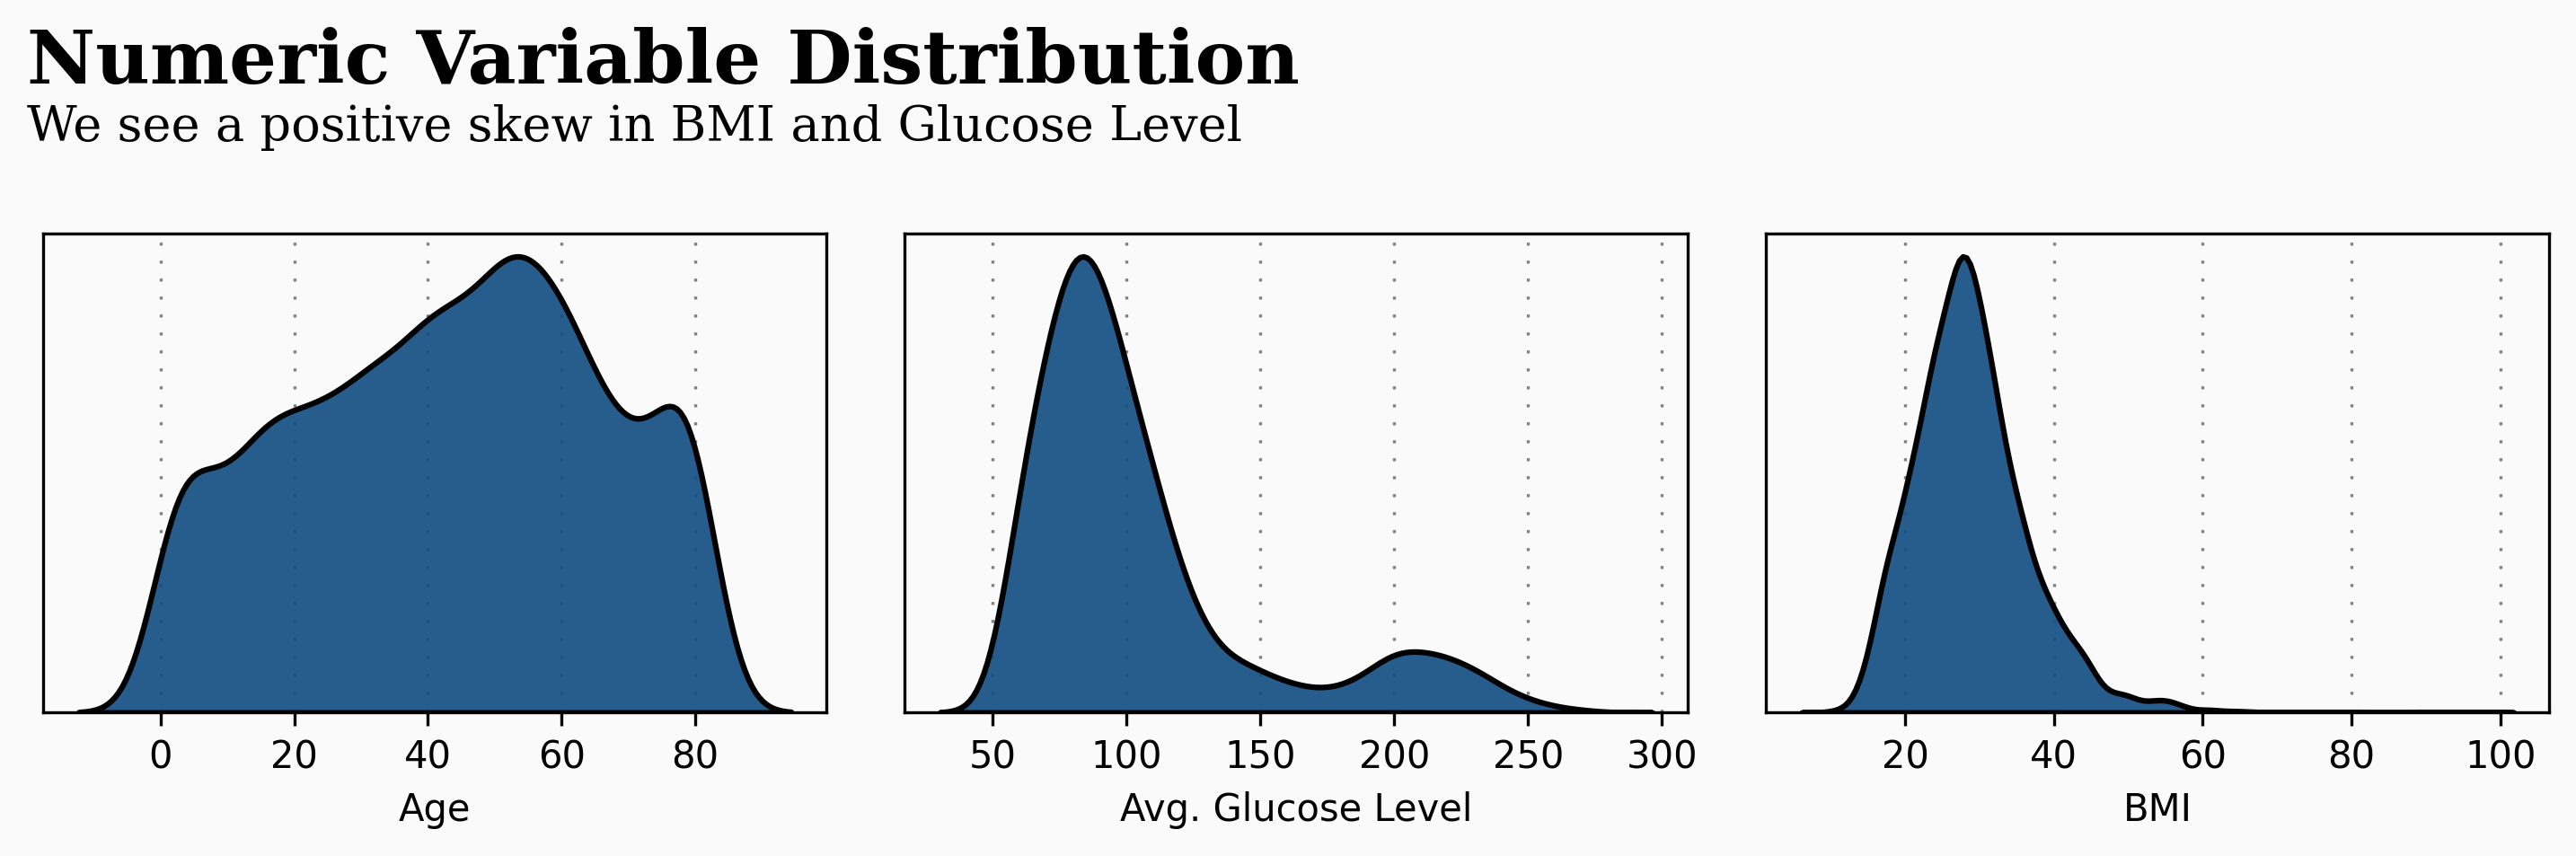

In [9]:
from matplotlib.typing import LineStyleType
import seaborn as sns
import matplotlib.pyplot as plt


vars = [var for var in df_knn.columns if var not in ['id','stroke']]
conts = ['age','avg_glucose_level','bmi']

fig = plt.figure(figsize=(12,12),dpi=300,facecolor='#fafafa')
gs = fig.add_gridspec(4,3)
gs.update(wspace=0.1, hspace=0.4)

background_color = '#fafafa'
plot = 0
for row in range(0,1):
  for col in range(0,3):
    locals()['ax' + str(plot)] = fig.add_subplot(gs[row,col])
    locals()['ax' + str(plot)].set_facecolor(background_color)
    locals()['ax' + str(plot)].tick_params(axis='y', left=False)
    locals()['ax' + str(plot)].get_yaxis().set_visible(False)
    for s in ['top','right','left','bottom']:
      locals()['ax' + str(plot)].spines[s].set_visible(True)
    plot +=1
plot = 0
for variable in conts:
  sns.kdeplot(df_knn[variable],
              ax=locals()['ax' + str(plot)],
              color='#0f4c81',
              shade=True,
              linewidth=1.5,
              ec='black',
              alpha=0.9,
              zorder=3,
              legend=True)
  locals()['ax' + str(plot)].grid(which='major',
                                  axis='x',
                                  zorder=0,
                                  color='gray',
                                  linestyle=':',
                                  dashes=(1,5))
  plot += 1

ax0.set_xlabel('Age')
ax1.set_xlabel('Avg. Glucose Level')
ax2.set_xlabel('BMI')

ax0.text(-20,0.022,'Numeric Variable Distribution',fontsize=20,fontweight='bold',fontfamily='serif')
ax0.text(-20, 0.02, 'We see a positive skew in BMI and Glucose Level', fontsize=13, fontweight='light', fontfamily='serif')
plt.show()


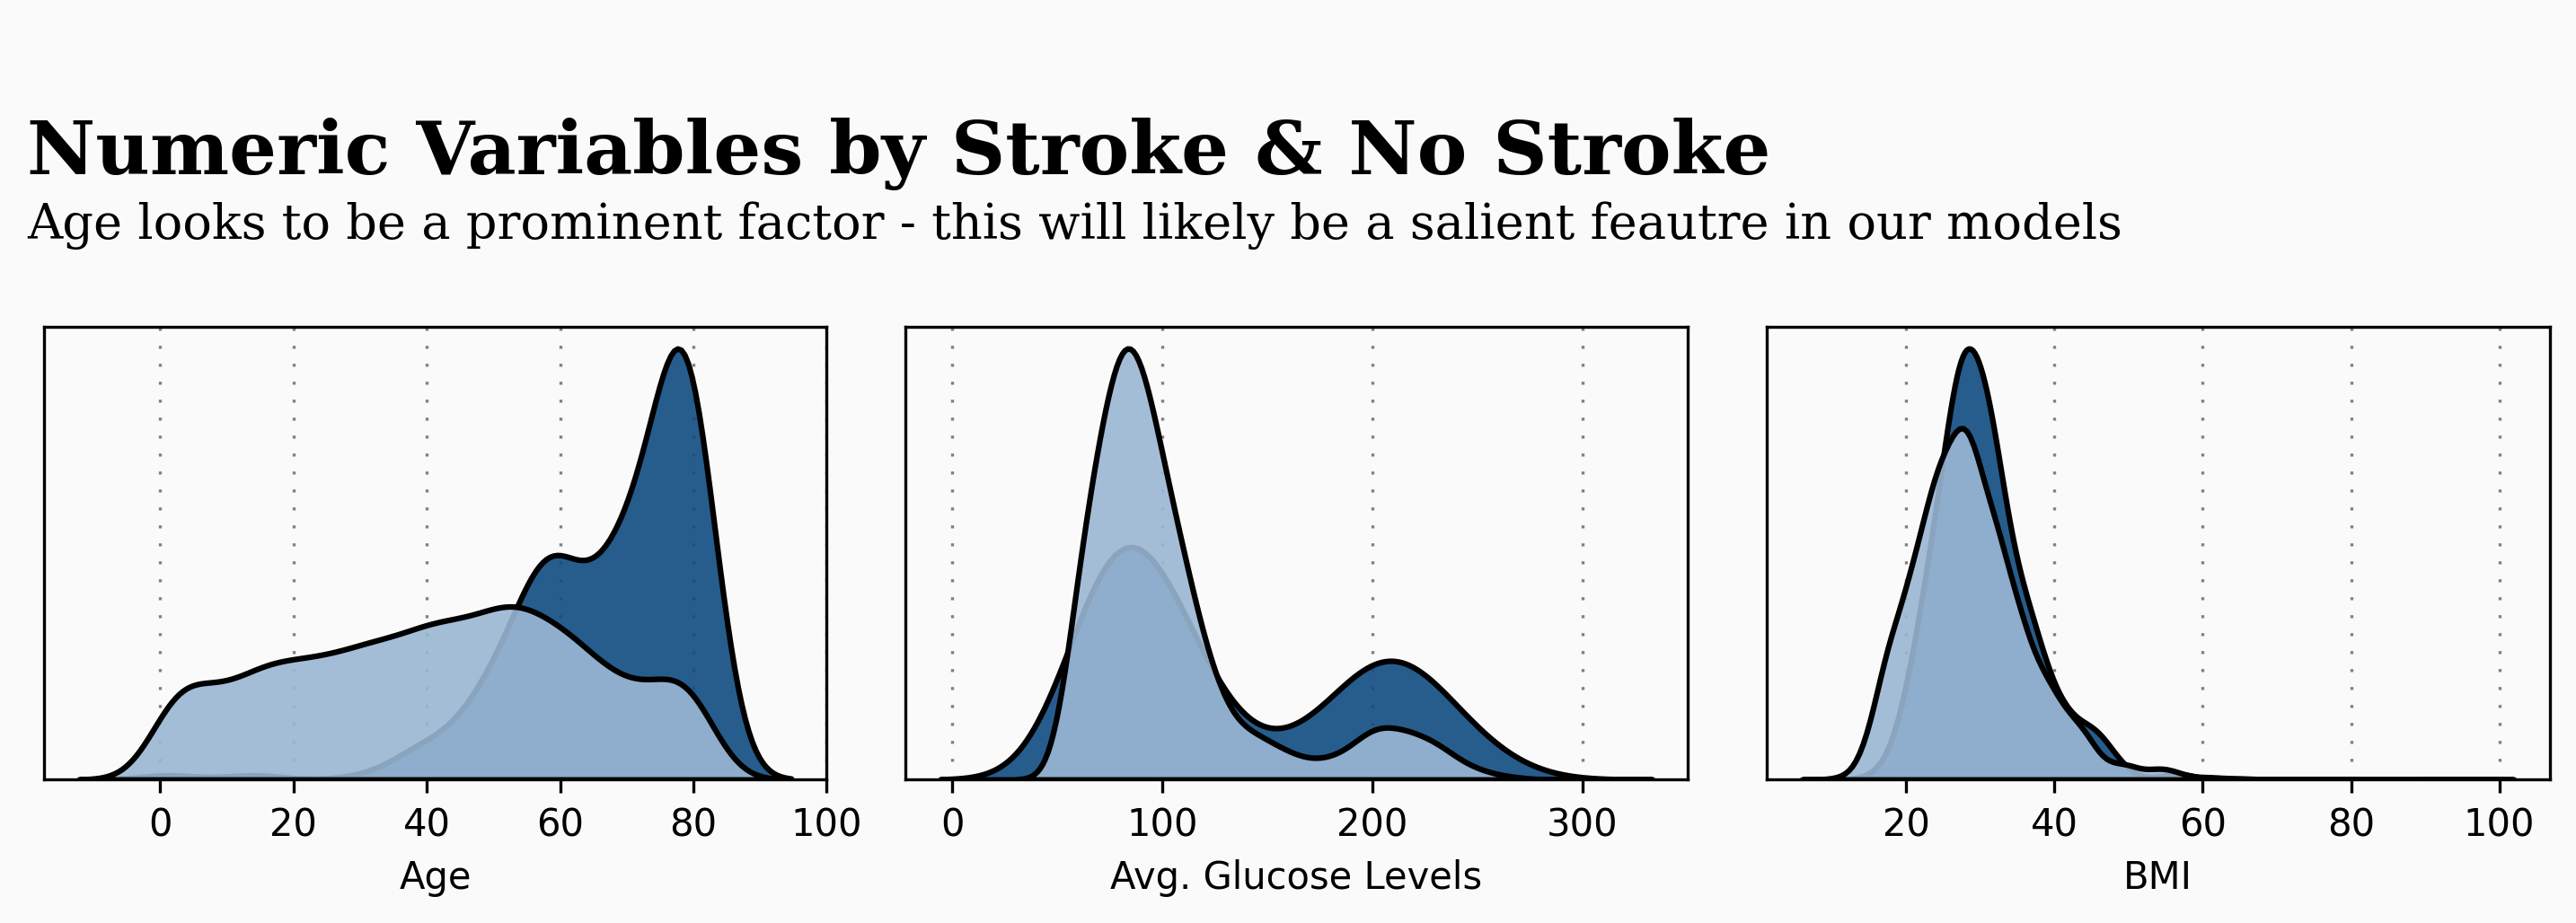

In [10]:
fig = plt.figure(figsize=(12, 12), dpi=300,facecolor=background_color)
gs = fig.add_gridspec(4, 3)
gs.update(wspace=0.1, hspace=0.5)


plot = 0
for row in range(0, 1):
    for col in range(0, 3):
        locals()["ax"+str(plot)] = fig.add_subplot(gs[row, col])
        locals()["ax"+str(plot)].set_facecolor(background_color)
        locals()["ax"+str(plot)].tick_params(axis='y', left=False)
        locals()["ax"+str(plot)].get_yaxis().set_visible(False)
        for s in ["top","right","left"]:
            locals()["ax"+str(plot)].spines[s].set_visible(True)
        plot += 1

plot = 0

s = df[df['stroke'] == 1]
ns = df[df['stroke'] == 0]

for feature in conts:
        sns.kdeplot(s[feature], ax=locals()["ax"+str(plot)], color='#0f4c81', shade=True, linewidth=1.5, ec='black',alpha=0.9, zorder=3, legend=False)
        sns.kdeplot(ns[feature],ax=locals()["ax"+str(plot)], color='#9bb7d4', shade=True, linewidth=1.5, ec='black',alpha=0.9, zorder=3, legend=False)
        locals()["ax"+str(plot)].grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
        plot += 1

ax0.set_xlabel('Age')
ax1.set_xlabel('Avg. Glucose Levels')
ax2.set_xlabel('BMI')

ax0.text(-20, 0.056, 'Numeric Variables by Stroke & No Stroke', fontsize=20, fontweight='bold', fontfamily='serif')
ax0.text(-20, 0.05, 'Age looks to be a prominent factor - this will likely be a salient feautre in our models',
         fontsize=13, fontweight='light', fontfamily='serif')
fig.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    fontsize=12,
    frameon=False
)
plt.show()

Here is a brief, key summary of what each plot in the image represents:

* **Age:** Shows a broad, wide-ranging distribution with a peak around **50–55 years old**. The dataset includes people from young ages up to 80+, but heavily covers middle-aged to older adults.


* **Avg. Glucose Level:** Strongly **right-skewed** and **bimodal** (two peaks). The major peak around **80–100 mg/dL** shows the healthy majority, while the smaller peak around **200–220 mg/dL** highlights a distinct group with elevated blood sugar levels.


* **BMI:** Strongly **right-skewed** with a single high peak around **28–30**. Most individuals fall into the overweight/obese categories, with a long right tail stretching toward extreme values (above 50).

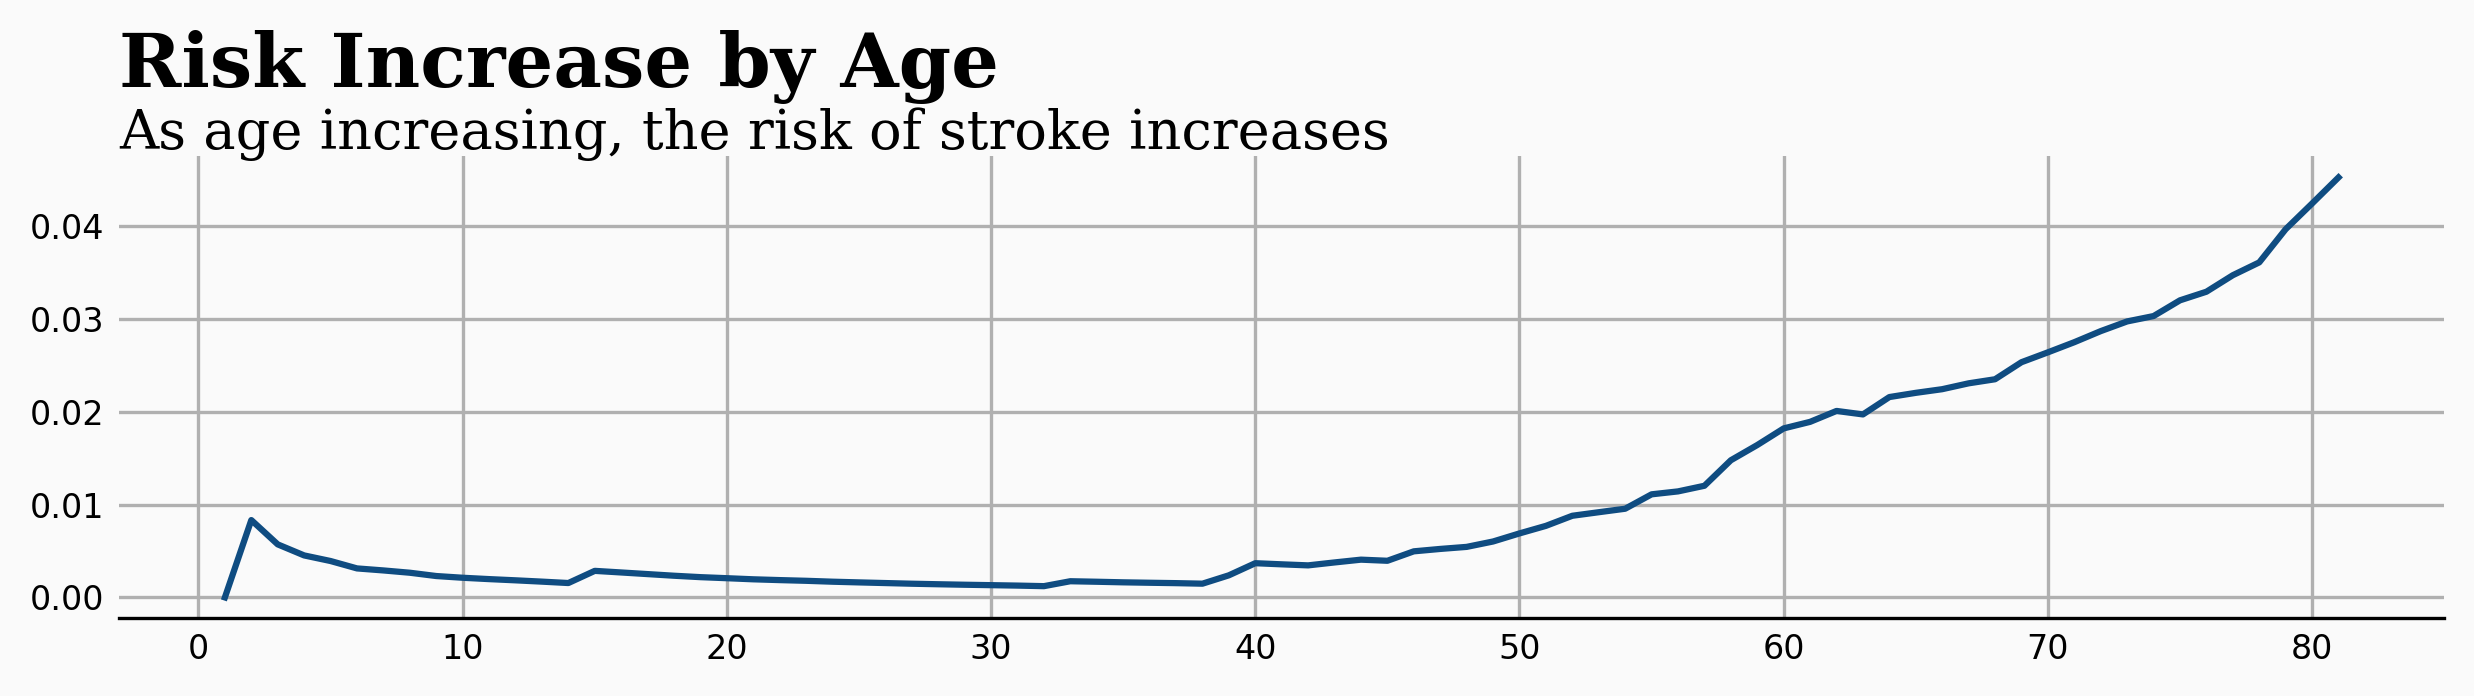

In [11]:
fig = plt.figure(figsize=(10,5),dpi=300,facecolor=background_color)
gs = fig.add_gridspec(2,1)
gs.update(wspace=0.11,hspace=0.5)
ax0 = fig.add_subplot(gs[0,0])
ax0.set_facecolor(background_color)

df['age'] = df['age'].astype(int)

rate = []
for i in range(df['age'].min(),df['age'].max()):
  subset = df[df['age'] < i]
  stroke_count = subset['stroke'].sum()
  total_count = len(subset)
  rate.append(stroke_count / total_count)

sns.lineplot(data=rate,color='#0f4c81',ax=ax0)
for s in ['top','left','right']:
  ax0.spines[s].set_visible(False)
ax0.tick_params(axis='both', which='major', labelsize=8)
ax0.tick_params(axis=u'both', which=u'both',length=0)
plt.grid(True)

ax0.text(-3,0.055,'Risk Increase by Age',fontsize=18,fontfamily='serif',fontweight='bold')
ax0.text(-3, 0.0483, 'As age increasing, the risk of stroke increases',
         fontsize=13, fontweight='light', fontfamily='serif')
plt.show()

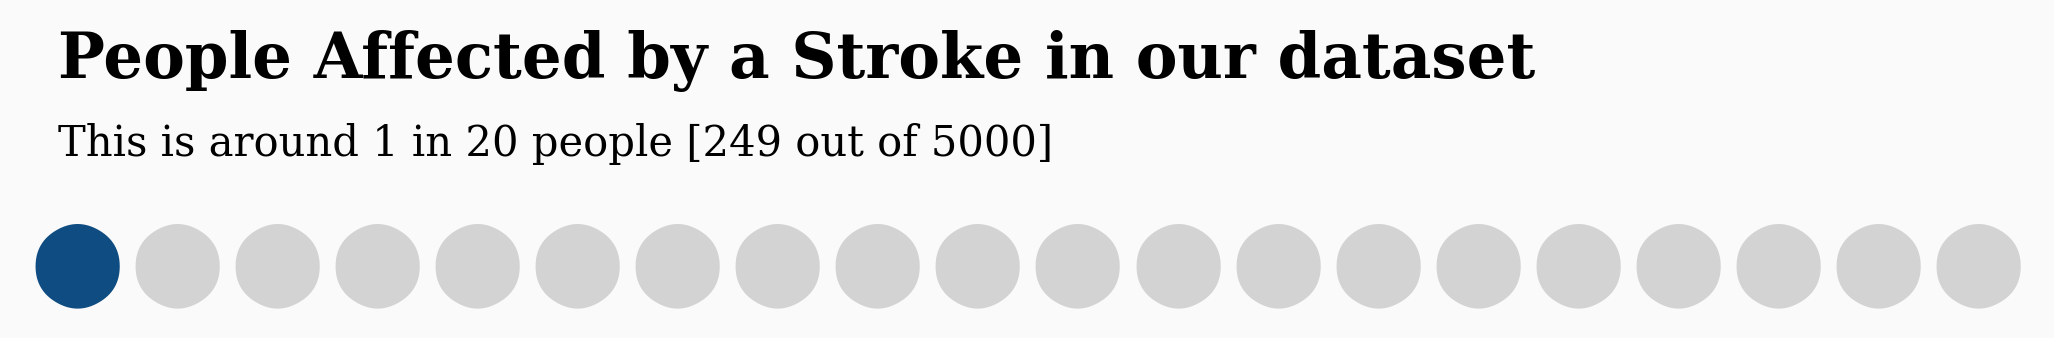

In [12]:
###CHECK DATA IMBALANCE
from pywaffle import Waffle
fig = plt.figure(figsize=(7, 2),dpi=300,facecolor=background_color,
    FigureClass=Waffle,
    rows=1,
    values=[1, 19],
    colors=['#0f4c81', "lightgray"],
    characters='⬤',
    font_size=20,vertical=True,
)
fig.text(0.035,0.78,'People Affected by a Stroke in our dataset',fontfamily='serif',fontsize=15,fontweight='bold')
fig.text(0.035,0.65,'This is around 1 in 20 people [249 out of 5000]',fontfamily='serif',fontsize=10)
plt.show()

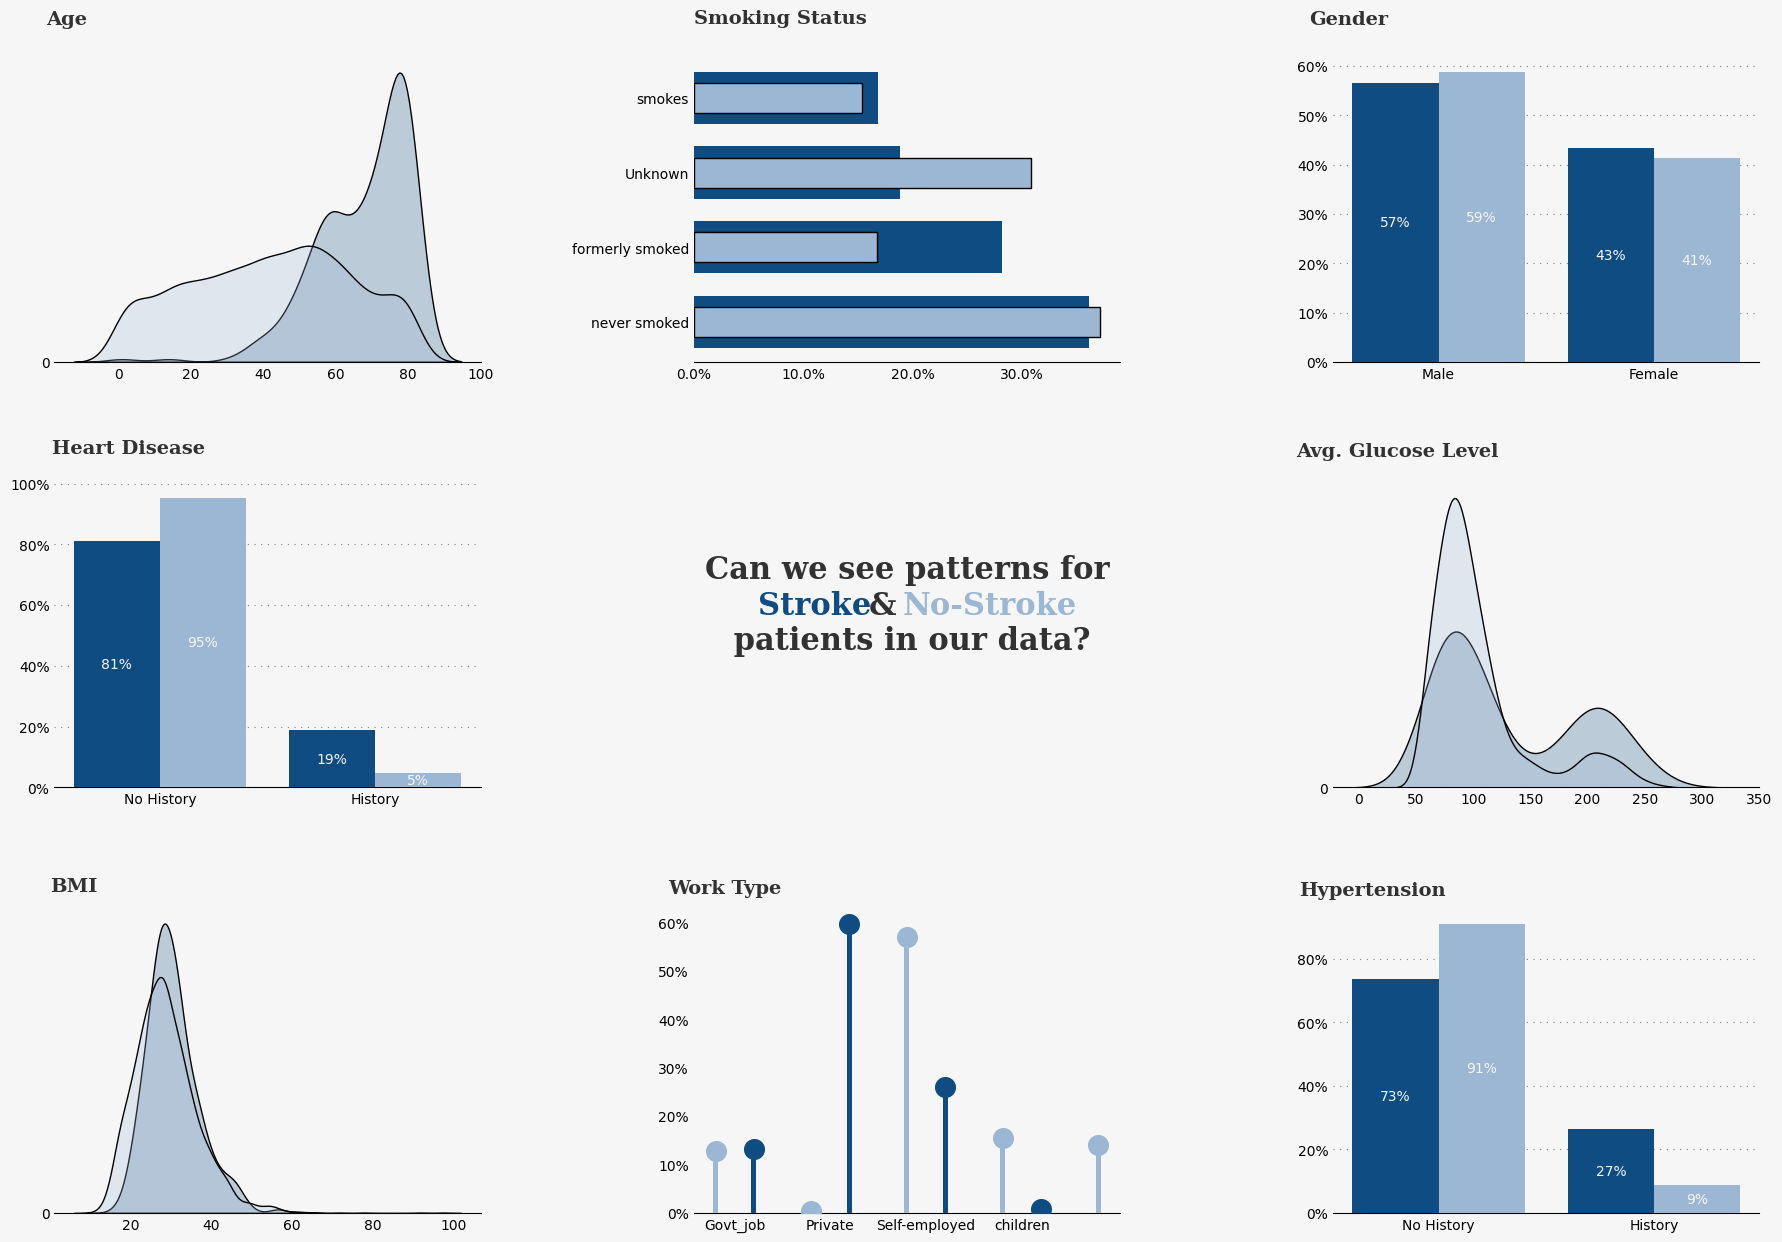

In [13]:
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import PercentFormatter

fig = plt.figure(figsize=(22,15))
gs = fig.add_gridspec(3,3)
gs.update(wspace=0.5,hspace=0.4)
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[0,2])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])
ax5 = fig.add_subplot(gs[1,2])
ax6 = fig.add_subplot(gs[2,0])
ax7 = fig.add_subplot(gs[2,1])
ax8 = fig.add_subplot(gs[2,2])

background_color = '#f6f6f6'
fig.patch.set_color(background_color)

# Filter out 'Other' gender
df_filtered = df[df['gender'] != 'Other'].copy()

str_only = df_filtered[df_filtered['stroke'] == 1]
no_str_only = df_filtered[df_filtered['stroke'] == 0]

##AGE
ax0.grid(color='gray',linestyle=':',axis='y',zorder=0,dashes=(1,5))
pos = pd.DataFrame(str_only['age'])
neg = pd.DataFrame(no_str_only['age'])
sns.kdeplot(pos['age'],ax=ax0,color='#0f4c81',shade=True,ec='black',label='positive')
sns.kdeplot(neg['age'],ax=ax0,color='#9bb7d4',shade=True,ec='black',label='negative')
ax0.yaxis.set_major_locator(MultipleLocator(2))
ax0.set_ylabel('')
ax0.set_xlabel('')
ax0.text(-20, 0.0465, 'Age', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")

##SMOKING
pos = pd.DataFrame(str_only['smoking_status'].value_counts())
neg = pd.DataFrame(no_str_only['smoking_status'].value_counts())

pos["percentage"] = pos["count"].apply(lambda x: x/sum(pos["count"])*100)
neg["percentage"] = neg["count"].apply(lambda x: x/sum(neg["count"])*100)

ax1.text(0, 4, 'Smoking Status', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
ax1.barh(pos.index,pos['percentage'],color='#0f4c81',label='positive',zorder=3,height=0.7)
ax1.barh(neg.index,neg['percentage'],color='#9bb7d4',label='negative',zorder=3,height=0.4,ec='black')
ax1.xaxis.set_major_formatter(PercentFormatter())
ax1.xaxis.set_major_locator(MultipleLocator(10))

##GENDER
pos = pd.DataFrame(str_only["gender"].value_counts())
pos["Percentage"] = pos["count"].apply(lambda x: x/sum(pos["count"])*100)
neg = pd.DataFrame(no_str_only["gender"].value_counts())
neg["Percentage"] = neg["count"].apply(lambda x: x/sum(neg["count"])*100)

x = np.arange(len(pos))
ax2.text(-0.4, 68.5, 'Gender', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
ax2.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax2.bar(x, height=pos["Percentage"], zorder=3, color="#0f4c81", width=0.4)
ax2.bar(x+0.4, height=neg["Percentage"], zorder=3, color="#9bb7d4", width=0.4)
ax2.set_xticks(x + 0.4 / 2)
ax2.set_xticklabels(['Male','Female'])
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.yaxis.set_major_locator(MultipleLocator(10))
for i,j in zip([0, 1], pos["Percentage"]):
    ax2.annotate(f'{j:0.0f}%',xy=(i, j/2), color='#f6f6f6', horizontalalignment='center', verticalalignment='center')
for i,j in zip([0, 1], neg["Percentage"]):
    ax2.annotate(f'{j:0.0f}%',xy=(i+0.4, j/2), color='#f6f6f6', horizontalalignment='center', verticalalignment='center')

##HEART DISEASE
pos = pd.DataFrame(str_only["heart_disease"].value_counts())
pos["percentage"] = pos["count"].apply(lambda x: x/sum(pos["count"])*100)
neg = pd.DataFrame(no_str_only["heart_disease"].value_counts())
neg['percentage'] = neg['count'].apply(lambda x: x/sum(neg['count'])*100)

x = np.arange(len(pos))
ax3.text(-0.3, 110, 'Heart Disease', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
ax3.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax3.bar(x, height=pos["percentage"], zorder=3, color="#0f4c81", width=0.4)
ax3.bar(x+0.4, height=neg["percentage"], zorder=3, color="#9bb7d4", width=0.4)
ax3.set_xticks(x + 0.4/2)
ax3.set_xticklabels(['No History','History'])
ax3.yaxis.set_major_formatter(PercentFormatter())
ax3.yaxis.set_major_locator(MultipleLocator(20))
for i,j in zip([0, 1], pos["percentage"]):
    ax3.annotate(f'{j:0.0f}%',xy=(i, j/2), color='#f6f6f6', horizontalalignment='center', verticalalignment='center')
for i,j in zip([0, 1], neg["percentage"]):
    ax3.annotate(f'{j:0.0f}%',xy=(i+0.4, j/2), color='#f6f6f6', horizontalalignment='center', verticalalignment='center')

ax4.spines['bottom'].set_visible(False)
ax4.tick_params(left=False,bottom=False)
ax4.set_xticklabels([])
ax4.set_yticklabels([])
ax4.text(0.5, 0.6, 'Can we see patterns for\n\n patients in our data?', horizontalalignment='center', verticalalignment='center',
         fontsize=22, fontweight='bold', fontfamily='serif', color="#323232")
ax4.text(0.15,0.57,"Stroke", fontweight="bold", fontfamily='serif', fontsize=22, color='#0f4c81')
ax4.text(0.41,0.57,"&", fontweight="bold", fontfamily='serif', fontsize=22, color='#323232')
ax4.text(0.49,0.57,"No-Stroke", fontweight="bold", fontfamily='serif', fontsize=22, color='#9bb7d4')


##GLUCLOSE
ax5.grid(color='gray',linestyle=':',axis='y',zorder=0,dashes=(1,5))
pos = pd.DataFrame(str_only['avg_glucose_level'])
neg = pd.DataFrame(no_str_only['avg_glucose_level'])
sns.kdeplot(pos['avg_glucose_level'],ax=ax5,color='#0f4c81',shade=True,ec='black',label='positive')
sns.kdeplot(neg['avg_glucose_level'],ax=ax5,color='#9bb7d4',shade=True,ec='black',label='negative')
ax5.text(-55, 0.01855, 'Avg. Glucose Level',fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
ax5.yaxis.set_major_locator(MultipleLocator(2))
ax5.set_ylabel('')
ax5.set_xlabel('')

##BMI
ax6.grid(color='gray',linestyle=':',axis='y',zorder=0,dashes=(1,5))
pos = pd.DataFrame(str_only['bmi'])
neg = pd.DataFrame(no_str_only['bmi'])
sns.kdeplot(pos['bmi'],ax=ax6,color='#0f4c81',shade=True,ec='black',label='positive')
sns.kdeplot(neg['bmi'],ax=ax6,color='#9bb7d4',shade=True,ec='black',label='negative')
ax6.text(-0.06, 0.078, 'BMI',
         fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
ax6.yaxis.set_major_locator(MultipleLocator(2))
ax6.set_ylabel('')
ax6.set_xlabel('')


##WORK TYPE
positive = pd.DataFrame(str_only["work_type"].value_counts())
positive["Percentage"] = positive["count"].apply(lambda x: x/sum(positive["count"])*100)
positive = positive.sort_index()

negative = pd.DataFrame(no_str_only["work_type"].value_counts())
negative["Percentage"] = negative["count"].apply(lambda x: x/sum(negative["count"])*100)
negative = negative.sort_index()

ax7.bar(negative.index, height=negative["Percentage"], zorder=3, color="#9bb7d4", width=0.05)
ax7.scatter(negative.index, negative["Percentage"], zorder=3,s=200, color="#9bb7d4")
ax7.bar(np.arange(len(positive.index))+0.4, height=positive["Percentage"], zorder=3, color="#0f4c81", width=0.05)
ax7.scatter(np.arange(len(positive.index))+0.4, positive["Percentage"], zorder=3,s=200, color="#0f4c81")

ax7.yaxis.set_major_formatter(PercentFormatter())
ax7.yaxis.set_major_locator(MultipleLocator(10))
ax7.set_xticks(np.arange(len(positive.index))+0.4 / 2)
ax7.set_xticklabels(list(positive.index),rotation=0)
ax7.text(-0.5, 66, 'Work Type', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")

##HYPERTENSION
positive = pd.DataFrame(str_only["hypertension"].value_counts())
positive["Percentage"] = positive["count"].apply(lambda x: x/sum(positive["count"])*100)
negative = pd.DataFrame(no_str_only["hypertension"].value_counts())
negative["Percentage"] = negative["count"].apply(lambda x: x/sum(negative["count"])*100)

x = np.arange(len(positive))
ax8.text(-0.45, 100, 'Hypertension', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
ax8.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax8.bar(x, height=positive["Percentage"], zorder=3, color="#0f4c81", width=0.4)
ax8.bar(x+0.4, height=negative["Percentage"], zorder=3, color="#9bb7d4", width=0.4)
ax8.set_xticks(x + 0.4 / 2)
ax8.set_xticklabels(['No History','History'])
ax8.yaxis.set_major_formatter(PercentFormatter())
ax8.yaxis.set_major_locator(MultipleLocator(20))
for i,j in zip([0, 1], positive["Percentage"]):
    ax8.annotate(f'{j:0.0f}%',xy=(i, j/2), color='#f6f6f6', horizontalalignment='center', verticalalignment='center')
for i,j in zip([0, 1], negative["Percentage"]):
    ax8.annotate(f'{j:0.0f}%',xy=(i+0.4, j/2), color='#f6f6f6', horizontalalignment='center', verticalalignment='center')

for s in ["top","right","left"]:
    for i in range(0,9):
        locals()["ax"+str(i)].spines[s].set_visible(False)

for i in range(0,9):
        locals()["ax"+str(i)].set_facecolor(background_color)
        locals()["ax"+str(i)].tick_params(axis=u'both', which=u'both',length=0)
        locals()["ax"+str(i)].set_facecolor(background_color)


plt.show()

<Axes: >

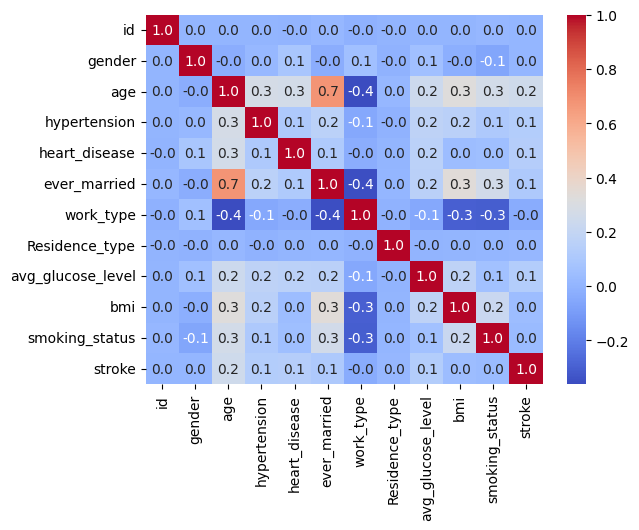

In [14]:
correlation_matrix = df_knn.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".1f", cmap="coolwarm")

##Outlier Detection & Treatment
Before moving to modeling, we check the three continuous variables (`age`, `avg_glucose_level`, `bmi`) for outliers using the IQR (Interquartile Range) method. Because the positive class (`stroke = 1`) is already rare (~5% of the data), we cap (winsorize) outliers to the IQR bounds instead of dropping the rows — removing rows risks deleting some of the already-scarce stroke-positive samples and worsening the imbalance further.

In [15]:
conts = ['age', 'avg_glucose_level', 'bmi']

def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

print("=== Outlier counts before treatment (IQR method, k=1.5) ===")
outlier_summary = []
for col in conts:
    s = df[col].dropna()
    low, high = iqr_bounds(s)
    n_outliers = int(((s < low) | (s > high)).sum())
    outlier_summary.append({
        'column': col,
        'lower_bound': round(low, 2),
        'upper_bound': round(high, 2),
        'n_outliers': n_outliers,
        'pct_outliers': round(100 * n_outliers / len(s), 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

=== Outlier counts before treatment (IQR method, k=1.5) ===


,column,lower_bound,upper_bound,n_outliers,pct_outliers
0,age,-29.00,115.00,0,0.00
1,avg_glucose_level,21.98,169.36,627,12.27
2,bmi,9.10,47.50,110,2.24


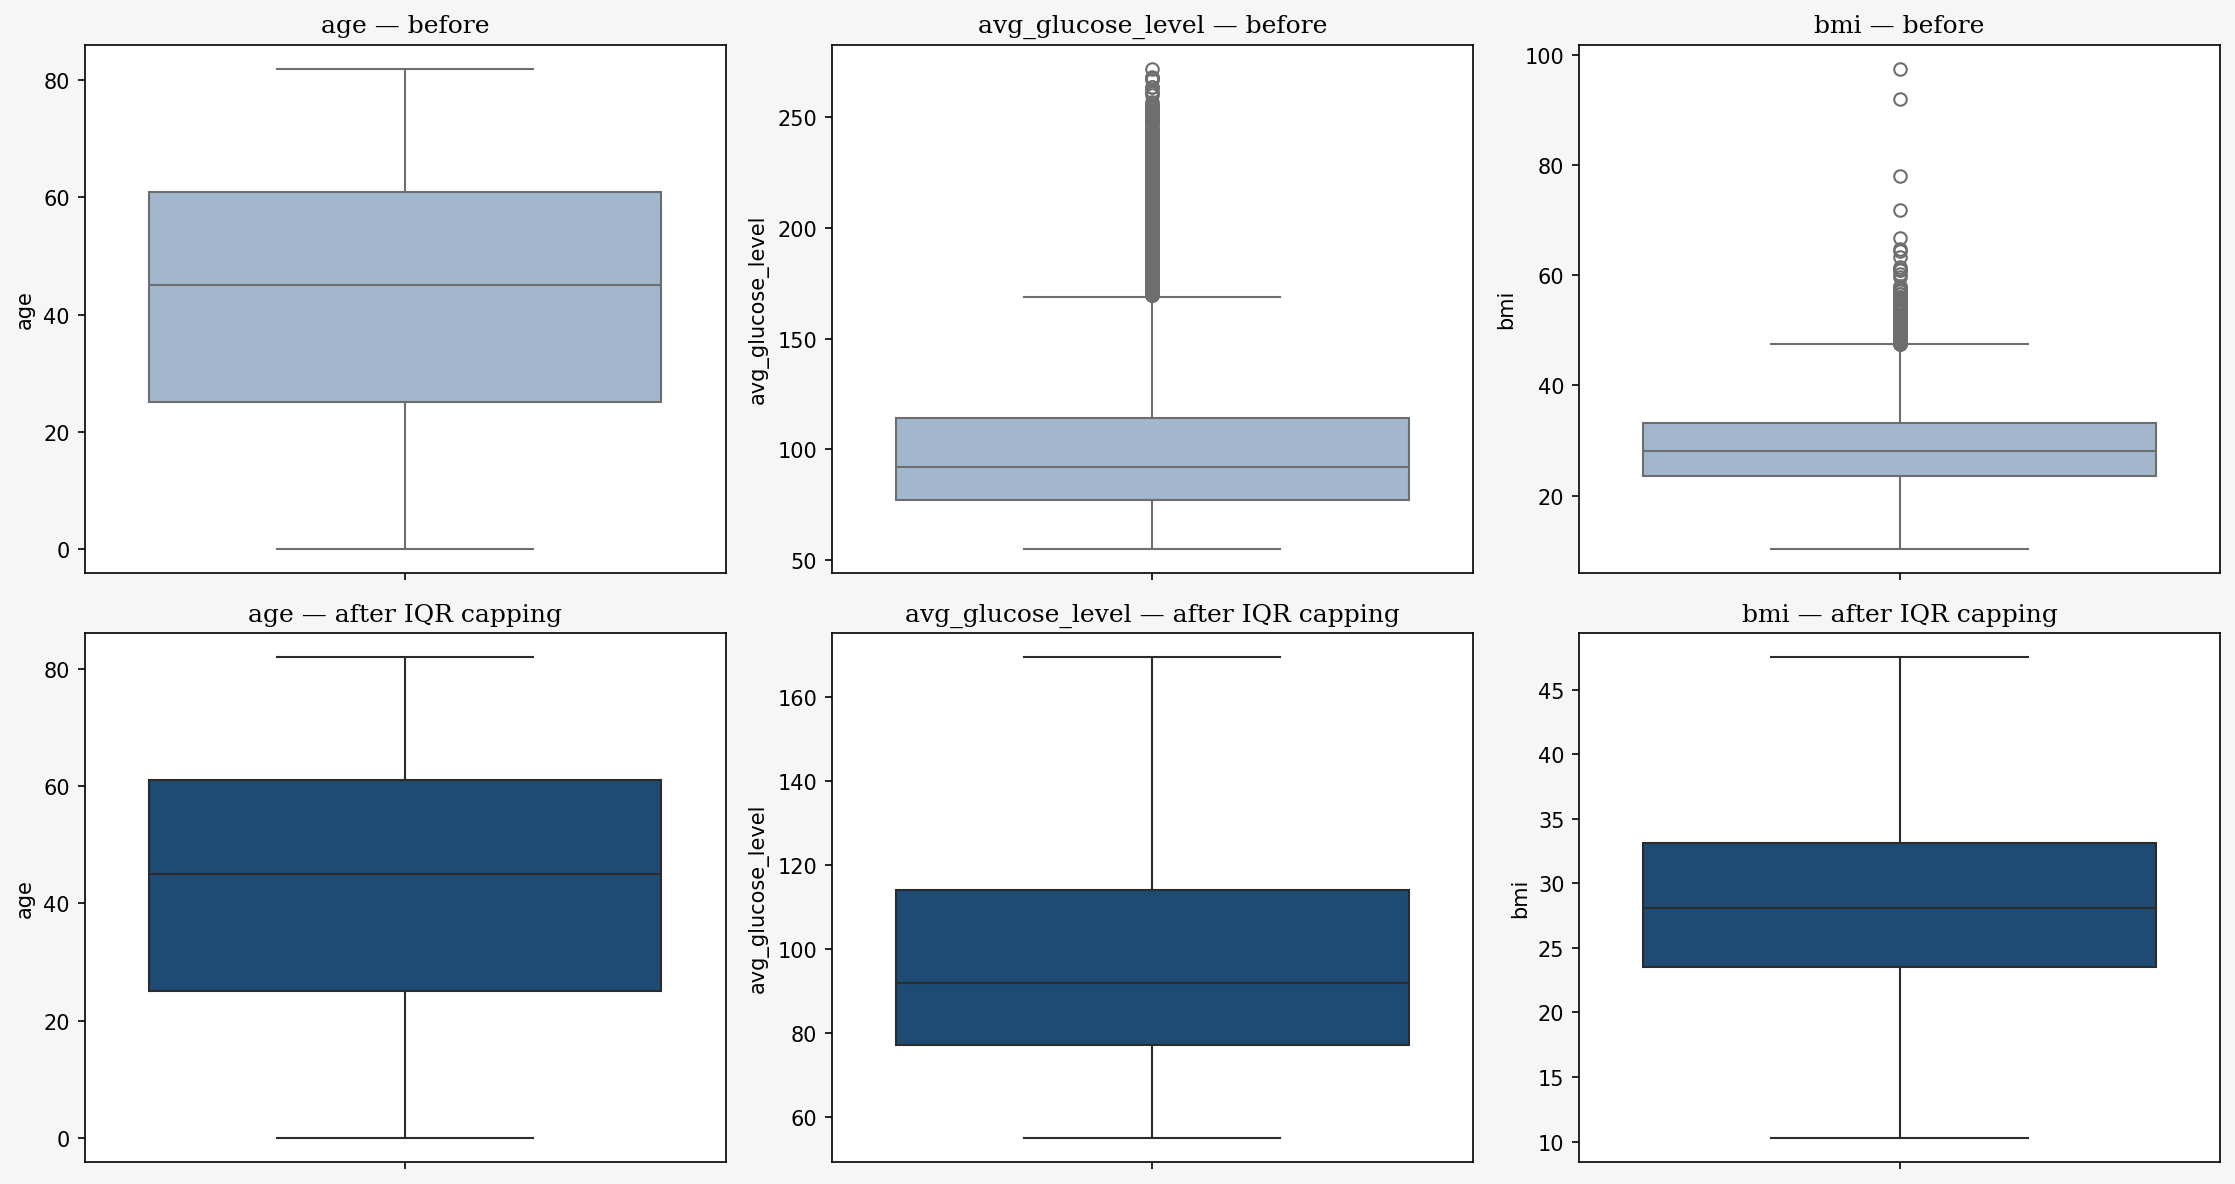

,min_before,max_before,min_after,max_after,bound_used
age,0.00,82.00,0.00,82.0000,"[-29.0, 115.0]"
avg_glucose_level,55.12,271.74,55.12,169.3575,"[22.0, 169.4]"
bmi,10.30,97.60,10.30,47.5000,"[9.1, 47.5]"



Conclusion: age has no extreme outliers (bounds cover the full observed range).
avg_glucose_level and bmi each have a real right-tail of extreme values that are
now capped to the IQR fence, which prevents them from dominating distance- and
gradient-based models (KNN imputer, MLP, Logistic Regression) while keeping every row.


In [16]:
before_clip = df[conts].copy()

bounds = {}
for col in conts:
    low, high = iqr_bounds(df[col].dropna())
    bounds[col] = (low, high)
    df[col] = df[col].clip(lower=low, upper=high)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=150, facecolor=background_color)
for i, col in enumerate(conts):
    sns.boxplot(y=before_clip[col], ax=axes[0, i], color='#9bb7d4')
    axes[0, i].set_title(f'{col} — before', fontsize=12, fontfamily='serif')
    sns.boxplot(y=df[col], ax=axes[1, i], color='#0f4c81')
    axes[1, i].set_title(f'{col} — after IQR capping', fontsize=12, fontfamily='serif')
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'min_before': before_clip[conts].min(),
    'max_before': before_clip[conts].max(),
    'min_after': df[conts].min(),
    'max_after': df[conts].max(),
    'bound_used': [f"[{bounds[c][0]:.1f}, {bounds[c][1]:.1f}]" for c in conts]
})
display(comparison)

print("\nConclusion: age has no extreme outliers (bounds cover the full observed range).")
print("avg_glucose_level and bmi each have a real right-tail of extreme values that are")
print("now capped to the IQR fence, which prevents them from dominating distance- and")
print("gradient-based models (KNN imputer, MLP, Logistic Regression) while keeping every row.")

##Modeling
Now, lets work with data processing and model training. We choose XGBoost, MLP, Logistic Classification and Random Forest as models to evaluate.

###DATA PROCESSING
Labels are unbalance, which stroke label is $\frac{1}{20}$ no stroke label. We apply SMOTE (Synthetic Minority Over-sampling Technique) to balance the dataset and LabelEncoding for encoding categorical attributes.



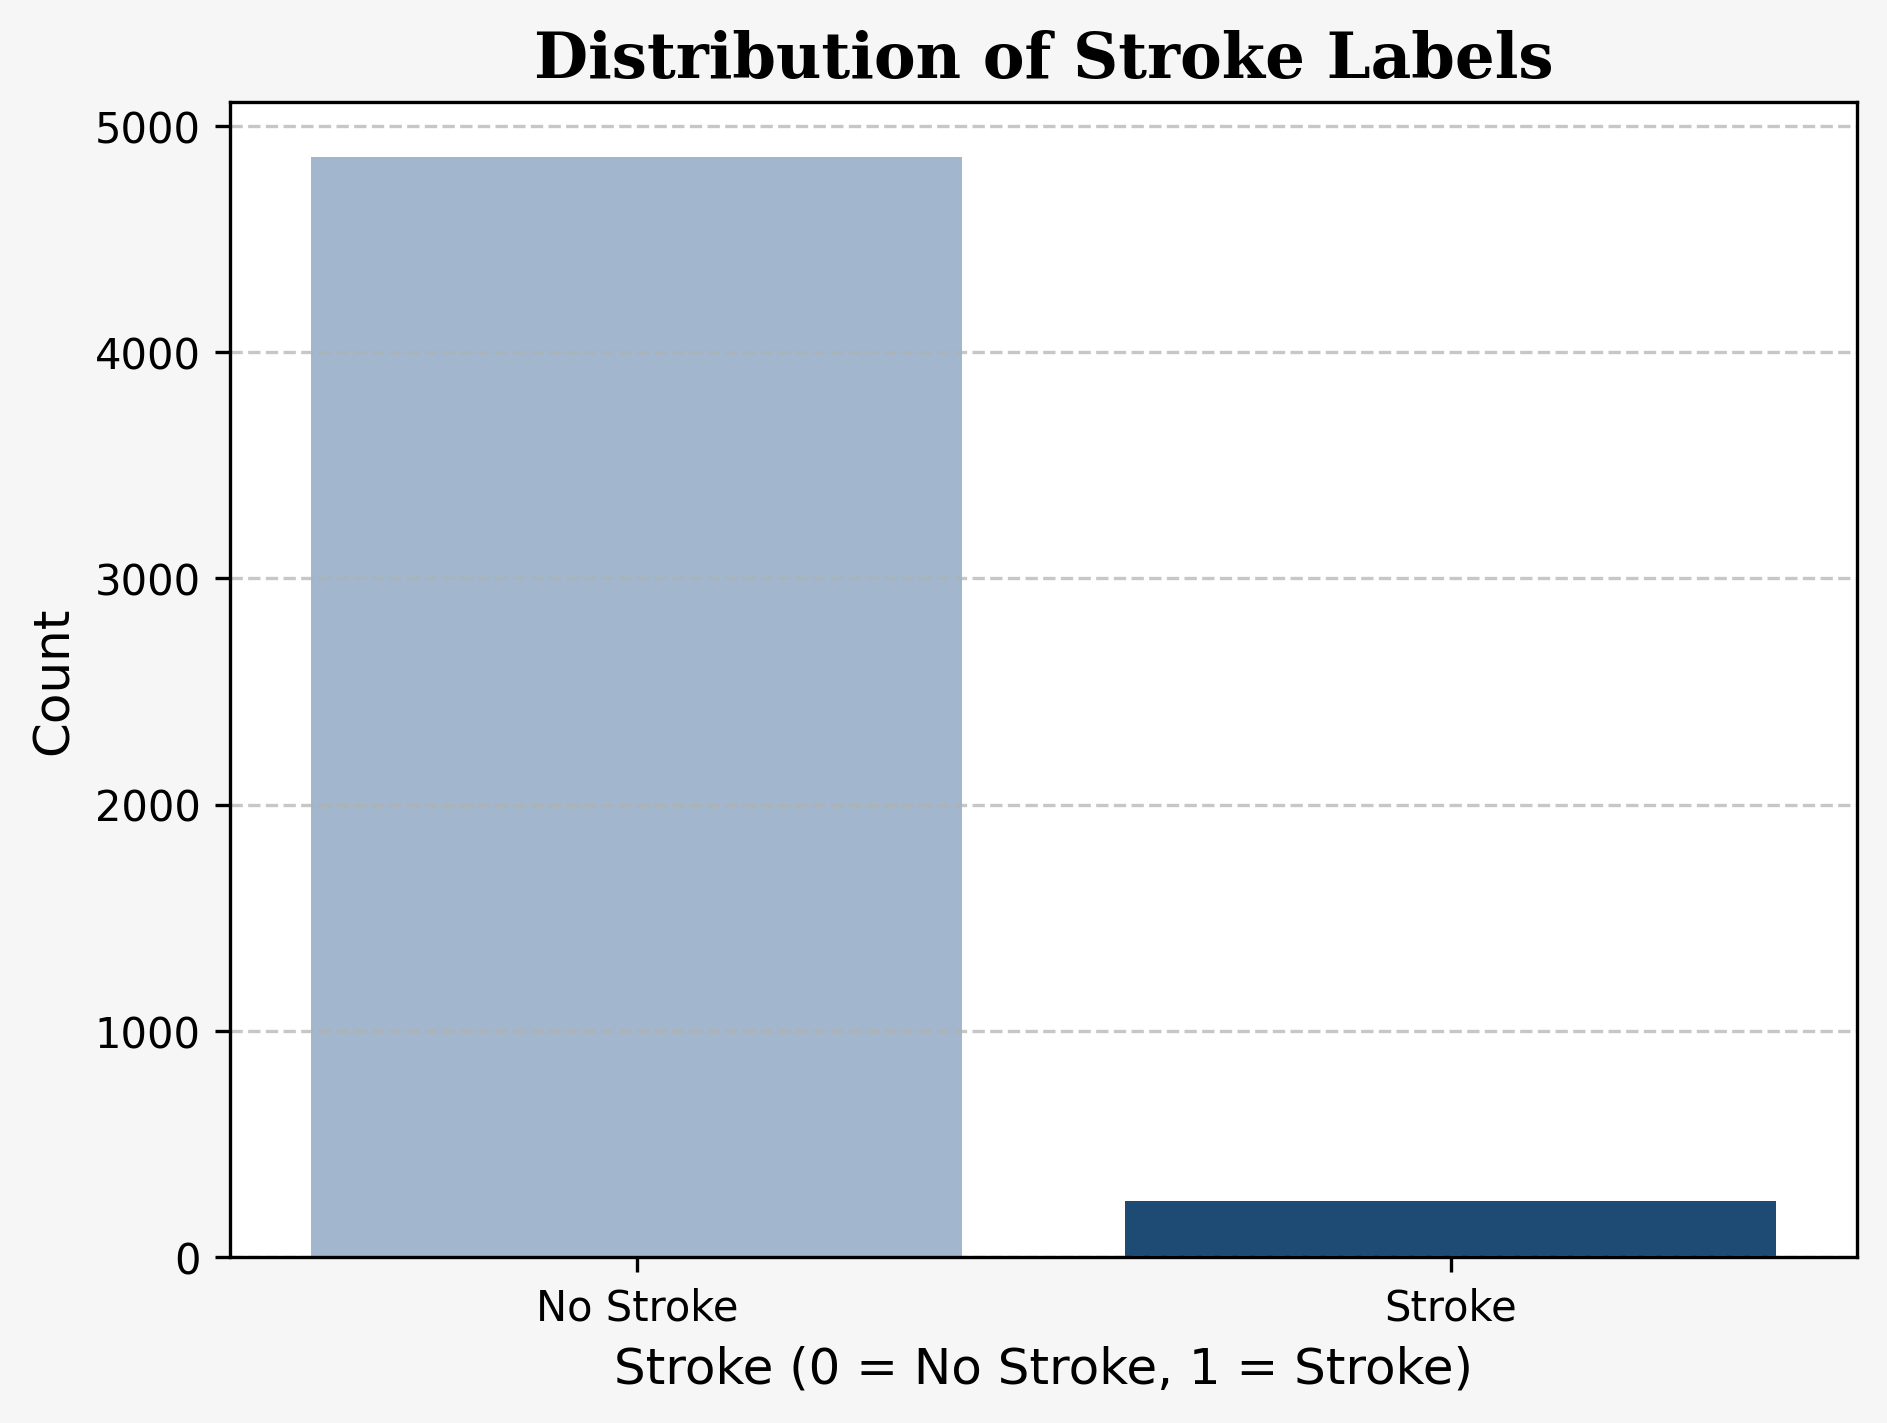

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

stroke_counts = df['stroke'].value_counts().reset_index()
stroke_counts.columns = ['stroke', 'count']

plt.figure(figsize=(7, 5), dpi=300, facecolor=background_color)
sns.barplot(x='stroke', y='count', data=stroke_counts, palette=['#9bb7d4', '#0f4c81'])
plt.title('Distribution of Stroke Labels', fontsize=15, fontweight='bold', fontfamily='serif')
plt.xlabel('Stroke (0 = No Stroke, 1 = Stroke)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['No Stroke', 'Stroke'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##FEATURE ENGINEERING
Because correlation between attributes and target attribute (stroke or no stroke) is extremely weak, we need to implement feature engineering for stronger correlation and enhancing models performance.

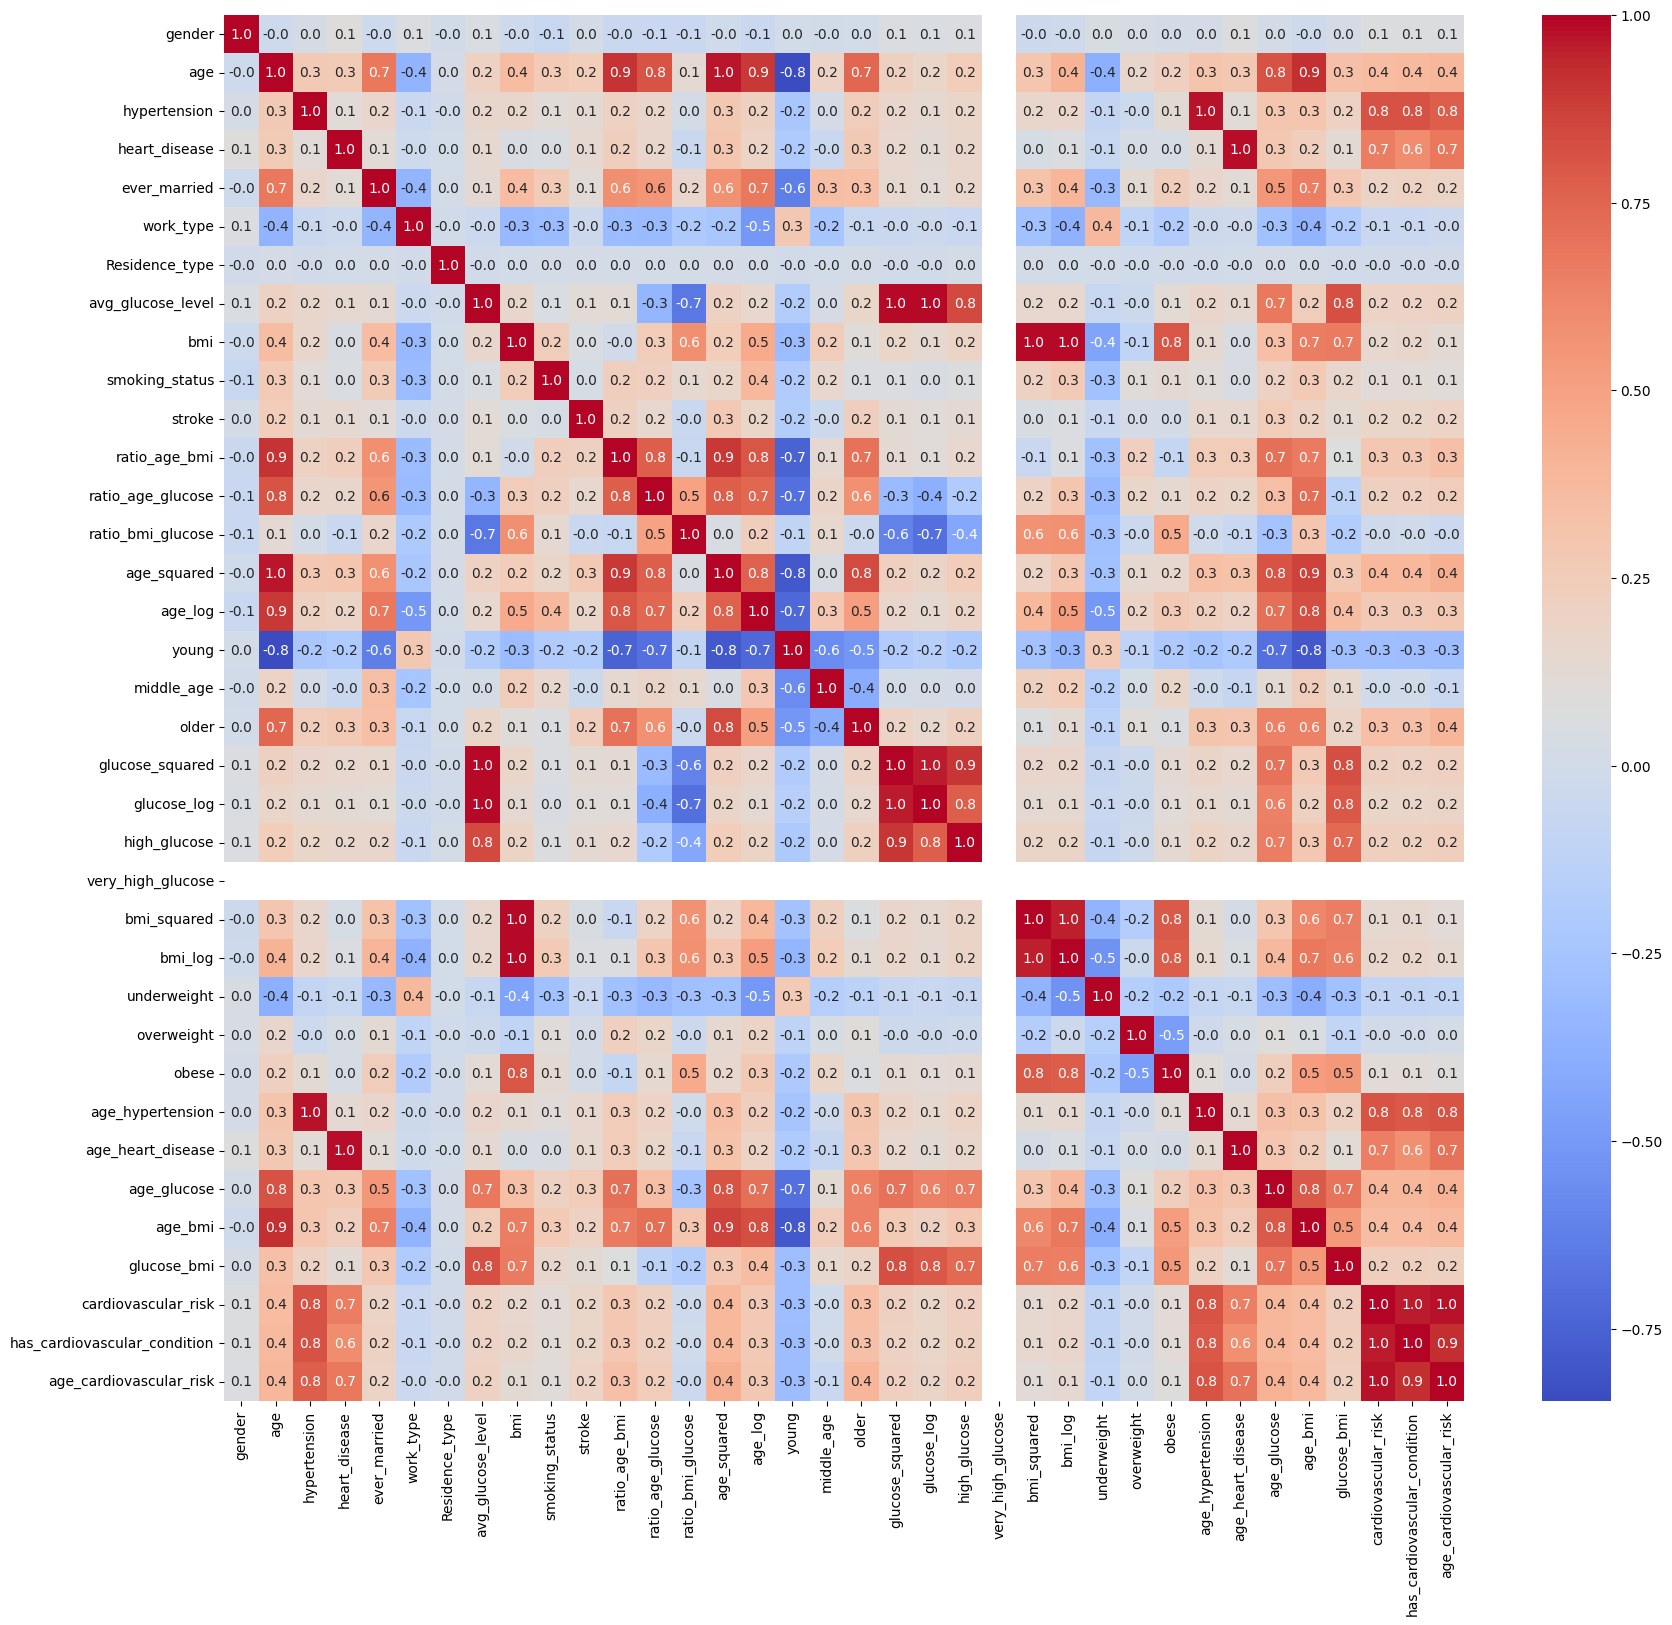

In [18]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder # Added import
import matplotlib.pyplot as plt # Added import
import seaborn as sns # Added import

# ============================================================
# 1. FEATURE ENGINEERING
# ============================================================

def create_features(df):
    df = df.copy()

    # --------------------------------------------------------
    # Remove ID
    # --------------------------------------------------------
    if 'id' in df.columns:
        df = df.drop(columns=['id'])

    # --------------------------------------------------------
    # Age-related features
    # --------------------------------------------------------
    df['age_squared'] = df['age'] ** 2
    df['age_log'] = np.log1p(df['age'])

    # Age groups
    df['young'] = (df['age'] < 40).astype(int)
    df['middle_age'] = ((df['age'] >= 40) & (df['age'] < 60)).astype(int)
    df['older'] = (df['age'] >= 60).astype(int)

    # --------------------------------------------------------
    # Glucose-related features
    # --------------------------------------------------------
    df['glucose_squared'] = df['avg_glucose_level'] ** 2
    df['glucose_log'] = np.log1p(df['avg_glucose_level'])

    # High glucose indicators
    df['high_glucose'] = (
        df['avg_glucose_level'] >= 140
    ).astype(int)

    df['very_high_glucose'] = (
        df['avg_glucose_level'] >= 200
    ).astype(int)

    # --------------------------------------------------------
    # BMI-related features
    # --------------------------------------------------------
    df['bmi_squared'] = df['bmi'] ** 2

    df['bmi_log'] = np.log1p(df['bmi'])

    df['underweight'] = (
        df['bmi'] < 18.5
    ).astype(int)

    df['overweight'] = (
        (df['bmi'] >= 25) & (df['bmi'] < 30)
    ).astype(int)

    df['obese'] = (
        df['bmi'] >= 30
    ).astype(int)

    # --------------------------------------------------------
    # Age × medical condition interactions
    # --------------------------------------------------------
    df['age_hypertension'] = (
        df['age'] * df['hypertension']
    )

    df['age_heart_disease'] = (
        df['age'] * df['heart_disease']
    )

    # --------------------------------------------------------
    # Age × glucose interaction
    # --------------------------------------------------------
    df['age_glucose'] = (
        df['age'] * df['avg_glucose_level']
    )

    # --------------------------------------------------------
    # Age × BMI interaction
    # --------------------------------------------------------
    df['age_bmi'] = (
        df['age'] * df['bmi']
    )

    # --------------------------------------------------------
    # Glucose × BMI interaction
    # --------------------------------------------------------
    df['glucose_bmi'] = (
        df['avg_glucose_level'] * df['bmi']
    )

    # --------------------------------------------------------
    # Combined cardiovascular risk indicator
    # --------------------------------------------------------
    df['cardiovascular_risk'] = (
        df['hypertension'] +
        df['heart_disease']
    )

    # Whether patient has either condition
    df['has_cardiovascular_condition'] = (
        (df['hypertension'] == 1) |
        (df['heart_disease'] == 1)
    ).astype(int)

    # --------------------------------------------------------
    # Age + cardiovascular condition
    # --------------------------------------------------------
    df['age_cardiovascular_risk'] = (
        df['age'] *
        df['cardiovascular_risk']
    )

    return df

numerical_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

df['ratio_age_bmi'] = df['age'] / df['bmi'].replace(0, np.nan)
df['ratio_age_glucose'] = df['age'] / df['avg_glucose_level'].replace(0, np.nan)
df['ratio_bmi_glucose'] = df['bmi'] / df['avg_glucose_level'].replace(0, np.nan)

df = create_features(df)

categorical_cols_to_encode = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
for col in categorical_cols_to_encode:
    if col in df.columns and df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

plt.figure(figsize=(20, 18)) # Increased figure size
cm = df.corr()
sns.heatmap(cm, annot=True, fmt=".1f", cmap="coolwarm") # Set annot=True
plt.show()

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE

categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

X = df.drop('stroke', axis=1)
y = df['stroke']

numerical_cols = [c for c in X.columns if c not in categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

num_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

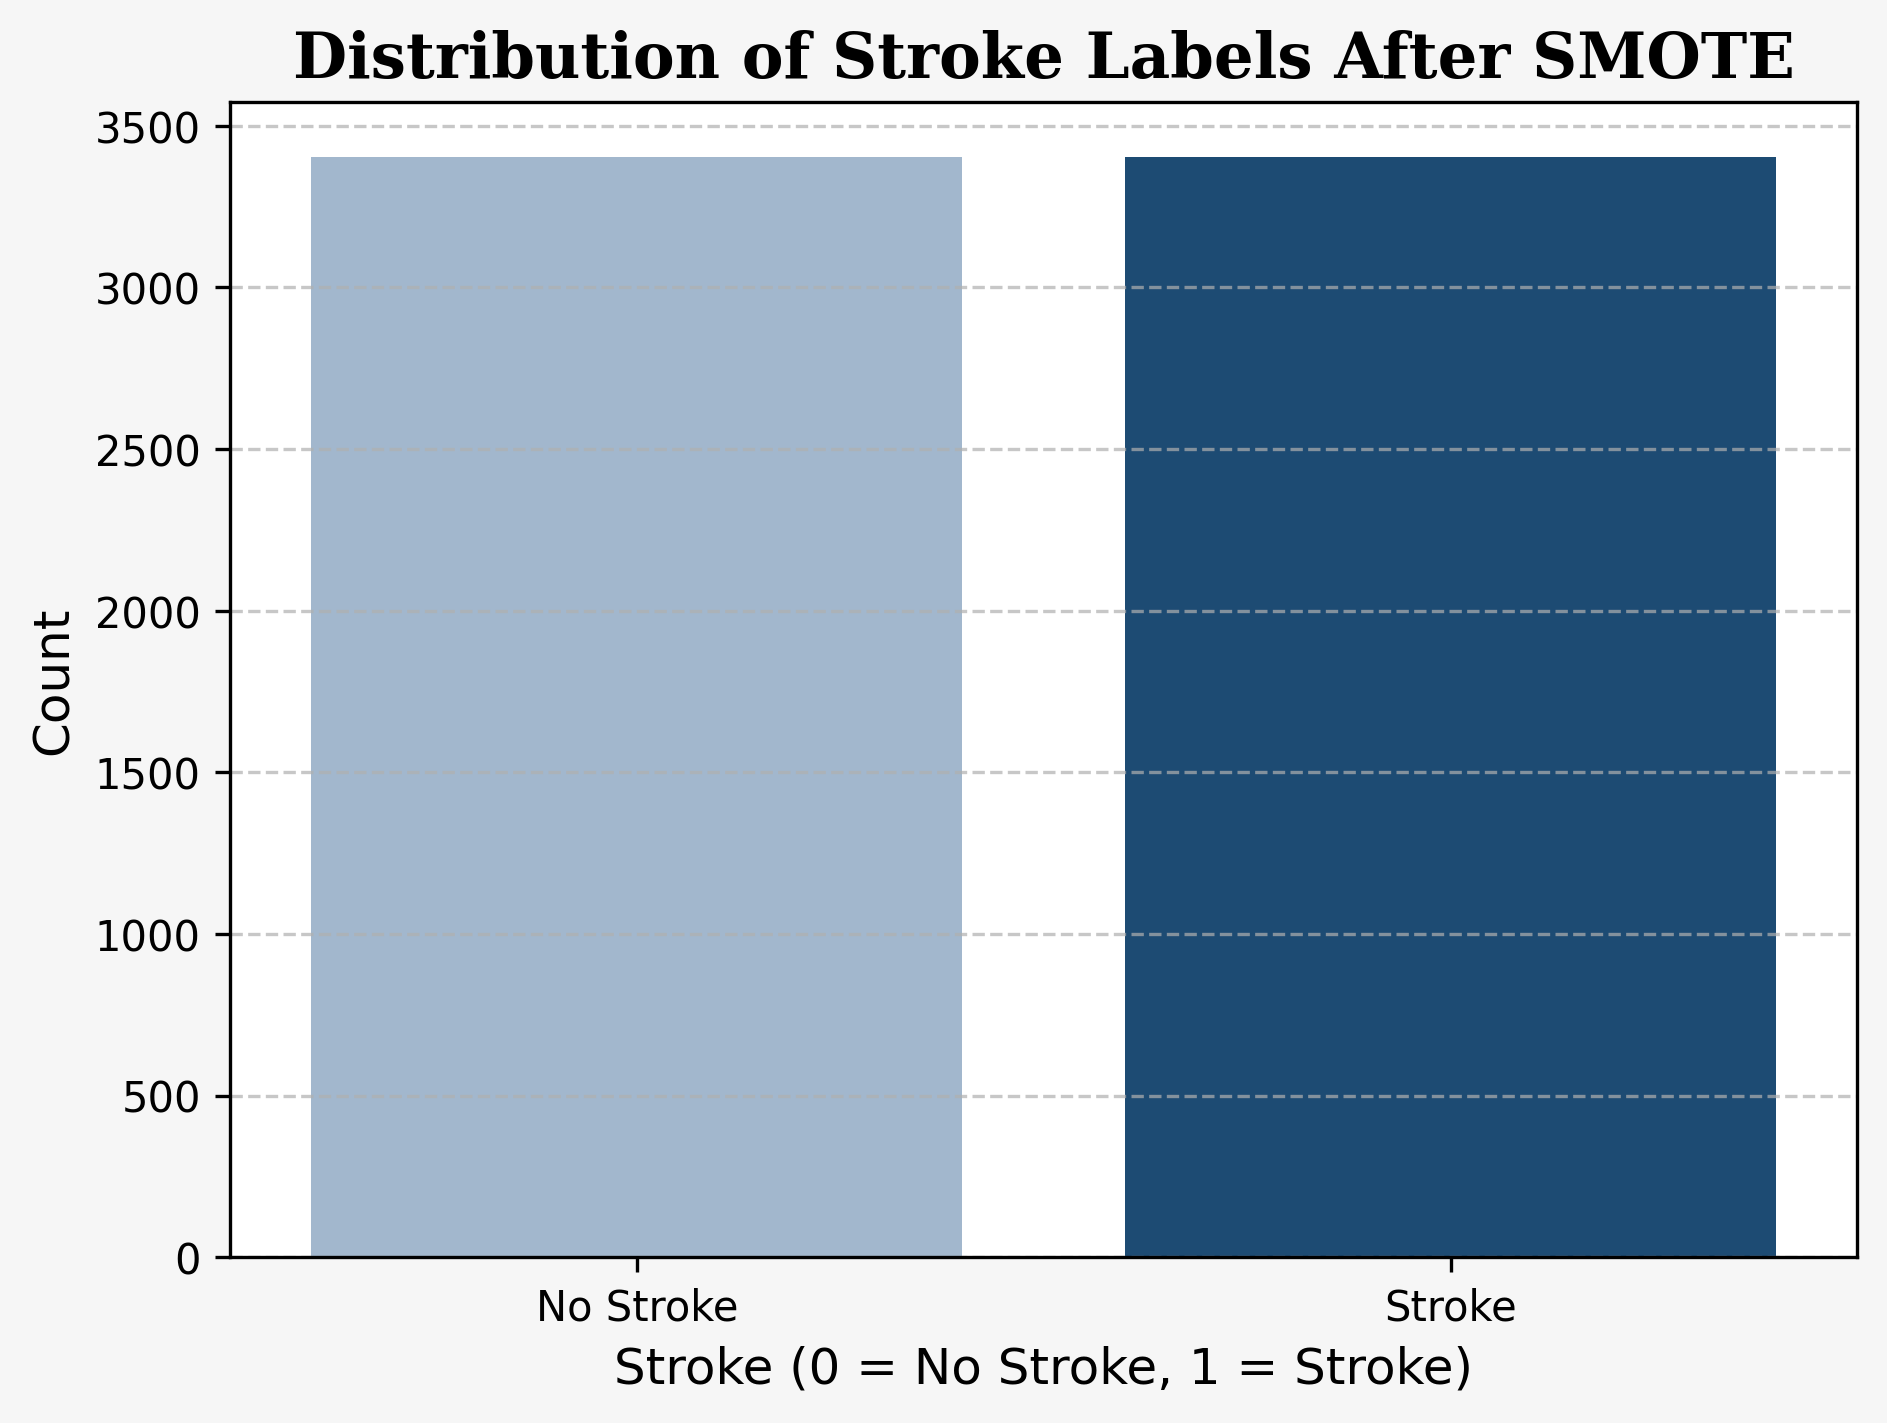

In [20]:
smote_counts = pd.Series(y_train_resampled).value_counts().reset_index()
smote_counts.columns = ['stroke', 'count']

plt.figure(figsize=(7, 5), dpi=300, facecolor=background_color)
sns.barplot(x='stroke', y='count', data=smote_counts, palette=['#9bb7d4', '#0f4c81'])
plt.title('Distribution of Stroke Labels After SMOTE', fontsize=15, fontweight='bold', fontfamily='serif')
plt.xlabel('Stroke (0 = No Stroke, 1 = Stroke)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['No Stroke', 'Stroke'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [22]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")


Train shape: (3066, 35)
Validation shape: (1022, 35)
Test shape: (1022, 35)


In [23]:
from imblearn.over_sampling import BorderlineSMOTE

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

smote = BorderlineSMOTE(random_state=42, k_neighbors=5, kind='borderline-1')
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print(f"Resampled Train shape: {X_train_resampled.shape}")

Resampled Train shape: (5834, 46)


In [24]:
train_corr = X_train.copy()
train_corr['stroke'] = y_train.values

numeric_corr = (
    train_corr
    .corr(numeric_only=True)['stroke']
    .drop('stroke')
    .sort_values(key=abs, ascending=False)
)

print("Features most correlated with stroke:")
print(numeric_corr)

Features most correlated with stroke:
age_squared                     0.270855
age_glucose                     0.250853
age                             0.242396
older                           0.220251
age_bmi                         0.206105
ratio_age_bmi                   0.204773
young                          -0.184051
age_cardiovascular_risk         0.178740
age_log                         0.169509
cardiovascular_risk             0.161586
ratio_age_glucose               0.154133
has_cardiovascular_condition    0.150768
age_hypertension                0.136767
high_glucose                    0.135295
glucose_bmi                     0.133231
age_heart_disease               0.132340
glucose_squared                 0.129229
heart_disease                   0.125541
avg_glucose_level               0.118676
hypertension                    0.117004
glucose_log                     0.105228
ever_married                    0.099601
bmi_log                         0.062483
bmi                

In [25]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif

N_SELECTED_FEATURES = min(25, X_train_resampled.shape[1])

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=N_SELECTED_FEATURES
)
X_train_selected = selector.fit_transform(X_train_resampled, y_train_resampled)
X_val_selected = selector.transform(X_val_processed)
X_test_selected = selector.transform(X_test_processed)

print(f"Selected {N_SELECTED_FEATURES} of {X_train_resampled.shape[1]} features for RF/XGBoost")


pca = PCA(
    n_components=0.95,
    random_state=42
)

X_train_pca = pca.fit_transform(X_train_resampled)
X_val_pca = pca.transform(X_val_processed)
X_test_pca = pca.transform(X_test_processed)

print("Original dimensions:", X_train_processed.shape[1])
print("PCA dimensions:", X_train_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())

Selected 25 of 46 features for RF/XGBoost
Original dimensions: 46
PCA dimensions: 11
Explained variance: 0.950674674681872


###Model Training

In [26]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

# ============================================================
# HYPERPARAMETER TUNING (cross-validated, scored on F2)
# ============================================================
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1, zero_division=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --------------------------------------------------------------
# Random Forest — on the mutual-info-selected feature set
# --------------------------------------------------------------
rf_param_dist = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(4, 20),
    "min_samples_leaf": randint(2, 15),
    "min_samples_split": randint(2, 20),
    "max_features": ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        bootstrap=True,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    ),
    param_distributions=rf_param_dist,
    n_iter=40,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    random_state=42
)
rf_search.fit(X_train_selected, y_train_resampled)

print("=== Random Forest ===")
print("Best CV F2:", round(rf_search.best_score_, 4))
print("Best params:", rf_search.best_params_)

# --------------------------------------------------------------
# XGBoost — same feature set
# --------------------------------------------------------------
xgb_param_dist = {
    "n_estimators": randint(150, 600),
    "max_depth": randint(2, 8),
    "learning_rate": uniform(0.01, 0.19),
    "min_child_weight": randint(1, 12),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_alpha": uniform(0.0, 2.0),
    "reg_lambda": uniform(0.5, 2.5),
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    ),
    param_distributions=xgb_param_dist,
    n_iter=40,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    random_state=42
)
xgb_search.fit(X_train_selected, y_train_resampled)

print("\n=== XGBoost ===")
print("Best CV F2:", round(xgb_search.best_score_, 4))
print("Best params:", xgb_search.best_params_)

# --------------------------------------------------------------
# Logistic Regression — on the PCA feature set
# --------------------------------------------------------------
lr_param_dist = {
    "C": uniform(0.01, 10),
    "penalty": ["l1", "l2"],
}

lr_search = RandomizedSearchCV(
    LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    param_distributions=lr_param_dist,
    n_iter=20,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    random_state=42
)
lr_search.fit(X_train_pca, y_train_resampled)

print("\n=== Logistic Regression ===")
print("Best CV F2:", round(lr_search.best_score_, 4))
print("Best params:", lr_search.best_params_)

=== Random Forest ===
Best CV F2: 0.9646
Best params: {'max_depth': 16, 'max_features': 'log2', 'min_samples_leaf': 6, 'min_samples_split': 8, 'n_estimators': 370}

=== XGBoost ===
Best CV F2: 0.9655
Best params: {'colsample_bytree': np.float64(0.8083337040103294), 'learning_rate': np.float64(0.19262268462637636), 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 516, 'reg_alpha': np.float64(1.6574750183038587), 'reg_lambda': np.float64(1.3918833167339733), 'subsample': np.float64(0.7123738038749523)}

=== Logistic Regression ===
Best CV F2: 0.8672
Best params: {'C': np.float64(0.017787658410143285), 'penalty': 'l2'}


In [27]:
# ============================================================
# 9. MODEL TRAINING (using cross-validated, F2-tuned hyperparameters)
# ============================================================
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report
)
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": (
        lr_search.best_estimator_,
        X_train_pca,
        X_val_pca,
        X_test_pca,
        y_train_resampled
    ),

    "Random Forest": (
        rf_search.best_estimator_,
        X_train_selected,
        X_val_selected,
        X_test_selected,
        y_train_resampled
    ),

    "MLP Classifier": (
        MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=0.0001,
            learning_rate_init=0.001,
            batch_size=64,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=42
        ),
        X_train_pca,
        X_val_pca,
        X_test_pca,
        y_train_resampled
    ),

    "XGBoost": (
        xgb_search.best_estimator_,
        X_train_selected,
        X_val_selected,
        X_test_selected,
        y_train_resampled
    )
}

trained_models = {}
model_val_aucs = {}

for name, (
    model,
    Xtr,
    Xv,
    Xte,
    ytr
) in models.items():

    model.fit(Xtr, ytr)
    trained_models[name] = model

    val_preds = model.predict(Xv)
    val_probs = model.predict_proba(Xv)[:, 1]
    val_auc = roc_auc_score(y_val, val_probs)
    model_val_aucs[name] = val_auc

    test_preds = model.predict(Xte)
    test_probs = model.predict_proba(Xte)[:, 1]
    test_auc = roc_auc_score(y_test, test_probs)

    print(f"==================== {name} ====================")

    print("--- Validation Set ---")
    print(
        f"Accuracy: {accuracy_score(y_val, val_preds):.4f} | "
        f"ROC AUC: {val_auc:.4f}"
    )
    print(classification_report(
        y_val,
        val_preds,
        zero_division=0
    ))

    print("--- Test Set ---")
    print(
        f"Accuracy: {accuracy_score(y_test, test_preds):.4f} | "
        f"ROC AUC: {test_auc:.4f}"
    )
    print(classification_report(
        y_test,
        test_preds,
        zero_division=0
    ))
    print()

==================== Logistic Regression ====================
--- Validation Set ---
Accuracy: 0.7818 | ROC AUC: 0.8433
              precision    recall  f1-score   support

           0       0.98      0.78      0.87       972
           1       0.15      0.72      0.24        50

    accuracy                           0.78      1022
   macro avg       0.56      0.75      0.56      1022
weighted avg       0.94      0.78      0.84      1022

--- Test Set ---
Accuracy: 0.7828 | ROC AUC: 0.8272
              precision    recall  f1-score   support

           0       0.99      0.78      0.87       972
           1       0.16      0.78      0.26        50

    accuracy                           0.78      1022
   macro avg       0.57      0.78      0.57      1022
weighted avg       0.95      0.78      0.84      1022


==================== Random Forest ====================
--- Validation Set ---
Accuracy: 0.9374 | ROC AUC: 0.8184
              precision    recall  f1-score   support

    

In [28]:
import numpy as np
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score,
    recall_score, f1_score, fbeta_score, accuracy_score
)


weights = {
    name: max(auc - 0.5, 0) ** 2
    for name, auc in model_val_aucs.items()
}
total_weight = sum(weights.values())

def ensemble_probs(split):
    """split: 'val' or 'test'"""
    probs = None
    for name, (model, _Xtr, Xv, Xte, _ytr) in models.items():
        X_split = Xv if split == 'val' else Xte
        p = model.predict_proba(X_split)[:, 1] * weights[name]
        probs = p if probs is None else probs + p
    return probs / total_weight

val_ensemble_probs = ensemble_probs('val')
test_ensemble_probs = ensemble_probs('test')

BETA = 2
best_f2, best_thresh = -1, 0.5
for thresh in np.arange(0.01, 1.0, 0.01):
    preds = (val_ensemble_probs >= thresh).astype(int)
    score = fbeta_score(y_val, preds, beta=BETA, pos_label=1, zero_division=0)
    if score > best_f2:
        best_f2, best_thresh = score, thresh

test_preds = (test_ensemble_probs >= best_thresh).astype(int)

print("==================== Soft-Voting Ensemble (AUC-weighted) ====================")
print("Model weights:", {k: round(v, 3) for k, v in weights.items()})
print(f"Chosen threshold (best Val F{BETA}): {best_thresh:.2f}")
print(f"Test ROC AUC:   {roc_auc_score(y_test, test_ensemble_probs):.4f}")
print(f"Test PR AUC:    {average_precision_score(y_test, test_ensemble_probs):.4f}")
print(f"Test Precision: {precision_score(y_test, test_preds, zero_division=0):.4f}")
print(f"Test Recall:    {recall_score(y_test, test_preds, zero_division=0):.4f}")
print(f"Test F1:        {f1_score(y_test, test_preds, zero_division=0):.4f}")
print(f"Test F{BETA}:        {fbeta_score(y_test, test_preds, beta=BETA, zero_division=0):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, test_preds):.4f}")

==================== Soft-Voting Ensemble (AUC-weighted) ====================
Model weights: {'Logistic Regression': np.float64(0.118), 'Random Forest': np.float64(0.101), 'MLP Classifier': np.float64(0.031), 'XGBoost': np.float64(0.067)}
Chosen threshold (best Val F2): 0.22
Test ROC AUC:   0.8234
Test PR AUC:    0.2042
Test Precision: 0.1404
Test Recall:    0.8000
Test F1:        0.2388
Test F2:        0.4124
Test Accuracy:  0.7505


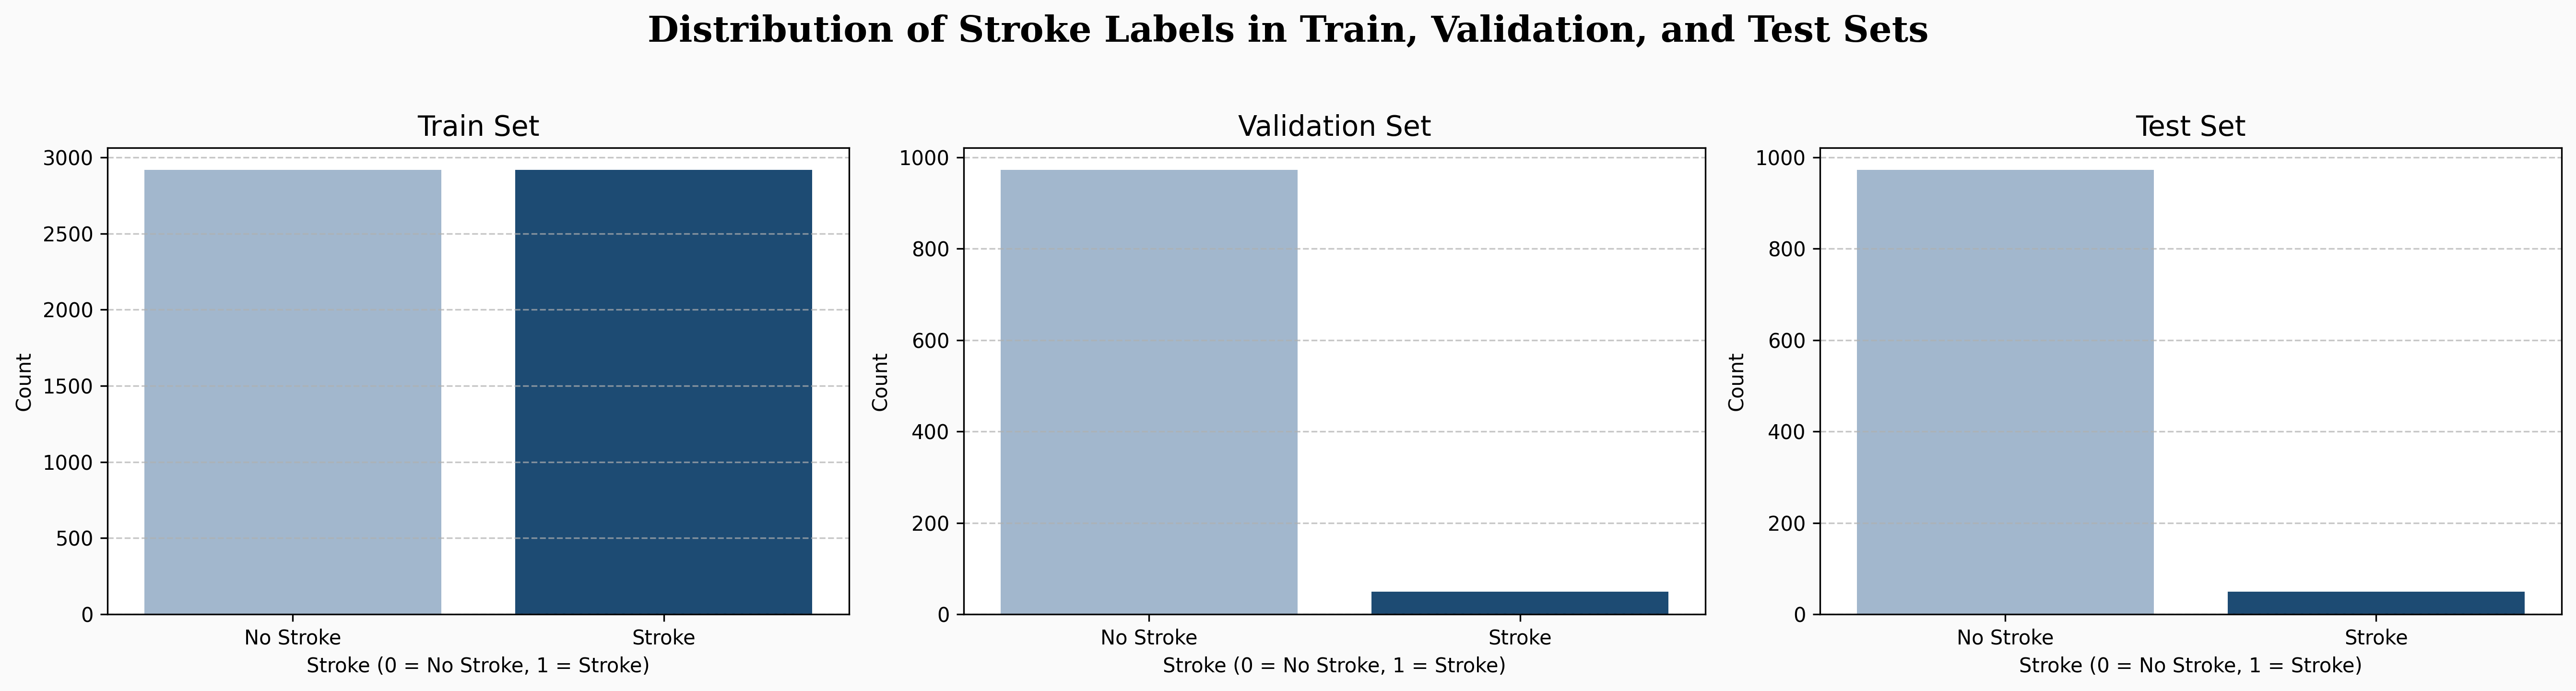

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

background_color = '#fafafa'

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=300, facecolor=background_color)
fig.suptitle('Distribution of Stroke Labels in Train, Validation, and Test Sets', fontsize=18, fontweight='bold', fontfamily='serif')

# Train Set Distribution
train_counts = pd.Series(y_train_resampled).value_counts().reset_index()
train_counts.columns = ['stroke', 'count']
sns.barplot(x='stroke', y='count', data=train_counts, palette=['#9bb7d4', '#0f4c81'], ax=axes[0])
axes[0].set_title('Train Set', fontsize=14)
axes[0].set_xlabel('Stroke (0 = No Stroke, 1 = Stroke)')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1], ['No Stroke', 'Stroke'])
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Validation Set Distribution
val_counts = pd.Series(y_val).value_counts().reset_index()
val_counts.columns = ['stroke', 'count']
sns.barplot(x='stroke', y='count', data=val_counts, palette=['#9bb7d4', '#0f4c81'], ax=axes[1])
axes[1].set_title('Validation Set', fontsize=14)
axes[1].set_xlabel('Stroke (0 = No Stroke, 1 = Stroke)')
axes[1].set_ylabel('Count')
axes[1].set_xticks([0, 1], ['No Stroke', 'Stroke'])
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Test Set Distribution
test_counts = pd.Series(y_test).value_counts().reset_index()
test_counts.columns = ['stroke', 'count']
sns.barplot(x='stroke', y='count', data=test_counts, palette=['#9bb7d4', '#0f4c81'], ax=axes[2])
axes[2].set_title('Test Set', fontsize=14)
axes[2].set_xlabel('Stroke (0 = No Stroke, 1 = Stroke)')
axes[2].set_ylabel('Count')
axes[2].set_xticks([0, 1], ['No Stroke', 'Stroke'])
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [40]:
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

dynamic_results = []

for name, model_tuple in models.items():
    model = model_tuple[0]
    X_te = model_tuple[3]

    test_preds = model.predict(X_te)
    test_probs = model.predict_proba(X_te)[:, 1]

    auc = roc_auc_score(y_test, test_probs)
    f1 = f1_score(y_test, test_preds, pos_label=1, zero_division=0)
    acc = accuracy_score(y_test, test_preds)

    dynamic_results.append({
        'Model': name,
        'Test ROC AUC': auc,
        'Test F1-Score (Stroke)': f1,
        'Test Accuracy': acc
    })

df_performance_dynamic = pd.DataFrame(dynamic_results).sort_values(by='Test ROC AUC', ascending=False).reset_index(drop=True)

styled_ranking_dynamic = df_performance_dynamic.style.background_gradient(
    cmap='Blues',
    subset=['Test ROC AUC', 'Test F1-Score (Stroke)', 'Test Accuracy']
).set_caption("Model Performance Ranking Table (Darker/Bolder = Higher Performance)") \
 .set_properties(**{'text-align': 'center', 'font-family': 'serif', 'border': '1px solid #ddd'}) \
 .format({'Test ROC AUC': '{:.4f}', 'Test F1-Score (Stroke)': '{:.2f}', 'Test Accuracy': '{:.4f}'})

styled_ranking_dynamic

,Model,Test ROC AUC,Test F1-Score (Stroke),Test Accuracy
0,Logistic Regression,0.8272,0.26,0.7828
1,Random Forest,0.8133,0.22,0.9384
2,XGBoost,0.7666,0.17,0.9413
3,MLP Classifier,0.7133,0.12,0.9178


In [41]:
best_row = df_performance_dynamic.iloc[0]
worst_row = df_performance_dynamic.iloc[-1]

print("=== Model ranking (by Test ROC AUC) ===")
display(df_performance_dynamic)

print(f"\nBest single model: {best_row['Model']} "
      f"(Test ROC AUC = {best_row['Test ROC AUC']:.4f}, "
      f"Test F1 = {best_row['Test F1-Score (Stroke)']:.2f}, "
      f"Test Accuracy = {best_row['Test Accuracy']:.4f})")
print(f"Weakest single model: {worst_row['Model']} "
      f"(Test ROC AUC = {worst_row['Test ROC AUC']:.4f})")

ens_thresh, ens_best = 0.5, -1
for t in np.arange(0.01, 1.0, 0.01):
    s = fbeta_score(y_val, (val_ensemble_probs >= t).astype(int),
                    beta=BETA, pos_label=1, zero_division=0)
    if s > ens_best:
        ens_best, ens_thresh = s, t
ens_preds = (test_ensemble_probs >= ens_thresh).astype(int)

print(f"\nAUC-weighted soft-voting ensemble (threshold {ens_thresh:.2f}, tuned for F{BETA} on validation): "
      f"Test ROC AUC = {roc_auc_score(y_test, test_ensemble_probs):.4f}, "
      f"Test Recall = {recall_score(y_test, ens_preds, zero_division=0):.2f}, "
      f"Test Precision = {precision_score(y_test, ens_preds, zero_division=0):.2f}, "
      f"Test F{BETA} = {fbeta_score(y_test, ens_preds, beta=BETA, zero_division=0):.4f}")

print("\nModel weights in the ensemble (validation-AUC based):",
      {k: round(v, 3) for k, v in weights.items()})

=== Model ranking (by Test ROC AUC) ===


,Model,Test ROC AUC,Test F1-Score (Stroke),Test Accuracy
0,Logistic Regression,0.827202,0.260000,0.782779
1,Random Forest,0.813251,0.222222,0.938356
2,XGBoost,0.766626,0.166667,0.941292
3,MLP Classifier,0.713251,0.125000,0.917808



Best single model: Logistic Regression (Test ROC AUC = 0.8272, Test F1 = 0.26, Test Accuracy = 0.7828)
Weakest single model: MLP Classifier (Test ROC AUC = 0.7133)

AUC-weighted soft-voting ensemble (threshold 0.22, tuned for F2 on validation): Test ROC AUC = 0.8234, Test Recall = 0.80, Test Precision = 0.14, Test F2 = 0.4124

Model weights in the ensemble (validation-AUC based): {'Logistic Regression': np.float64(0.118), 'Random Forest': np.float64(0.101), 'MLP Classifier': np.float64(0.031), 'XGBoost': np.float64(0.067)}


In [43]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    accuracy_score
)

BETA = 2

best_thresholds_list = []

for name, (model, _Xtr, Xv, _Xte, _ytr) in models.items():
    val_probs = model.predict_proba(Xv)[:, 1]

    best_fbeta = -1
    best_thresh = 0.5

    for thresh in np.arange(0.01, 1.0, 0.001):
        preds = (val_probs >= thresh).astype(int)
        score = fbeta_score(y_val, preds, beta=BETA, pos_label=1, zero_division=0)
        if score > best_fbeta:
            best_fbeta = score
            best_thresh = thresh

    best_thresholds_list.append({
        "Model": name,
        "Threshold": best_thresh,
        f"Val F{BETA}": best_fbeta
    })

best_thresholds = pd.DataFrame(best_thresholds_list)

final_threshold_results = []

for _, row in best_thresholds.iterrows():
    name = row["Model"]
    threshold = row["Threshold"]

    model, _Xtr, _Xv, Xte, _ytr = models[name]

    test_probs = model.predict_proba(Xte)[:, 1]
    test_preds = (
        test_probs >= threshold
    ).astype(int)

    final_threshold_results.append({
        "Model": name,
        "Threshold": threshold,
        "Test ROC AUC": roc_auc_score(
            y_test,
            test_probs
        ),
        "Test PR AUC": average_precision_score(
            y_test,
            test_probs
        ),
        "Test Precision": precision_score(
            y_test,
            test_preds,
            zero_division=0
        ),
        "Test Recall": recall_score(
            y_test,
            test_preds,
            zero_division=0
        ),
        "Test F1": f1_score(
            y_test,
            test_preds,
            zero_division=0
        ),
        f"Test F{BETA}": fbeta_score(
            y_test,
            test_preds,
            beta=BETA,
            zero_division=0
        ),
        "Test Accuracy": accuracy_score(
            y_test,
            test_preds
        )
    })

final_threshold_df = (
    pd.DataFrame(final_threshold_results)
    .sort_values(f"Test F{BETA}", ascending=False)
    .reset_index(drop=True)
)

display(
    final_threshold_df.style
    .background_gradient(
        cmap="Blues",
        subset=[
            "Test ROC AUC",
            "Test PR AUC",
            "Test Precision",
            "Test Recall",
            "Test F1",
            f"Test F{BETA}",
            "Test Accuracy"
        ]
    )
    .format({
        col: "{:.4f}"
        for col in final_threshold_df.columns
        if col != "Model"
    })
)

,Model,Threshold,Test ROC AUC,Test PR AUC,Test Precision,Test Recall,Test F1,Test F2,Test Accuracy
0,Logistic Regression,0.6170,0.8272,0.2308,0.1875,0.6600,0.2920,0.4388,0.8434
1,Random Forest,0.1400,0.8133,0.1926,0.1259,0.7400,0.2151,0.3745,0.7358
2,XGBoost,0.0100,0.7666,0.1641,0.1090,0.6800,0.1878,0.3320,0.7123
3,MLP Classifier,0.0140,0.7133,0.1220,0.1207,0.4200,0.1875,0.2807,0.8219


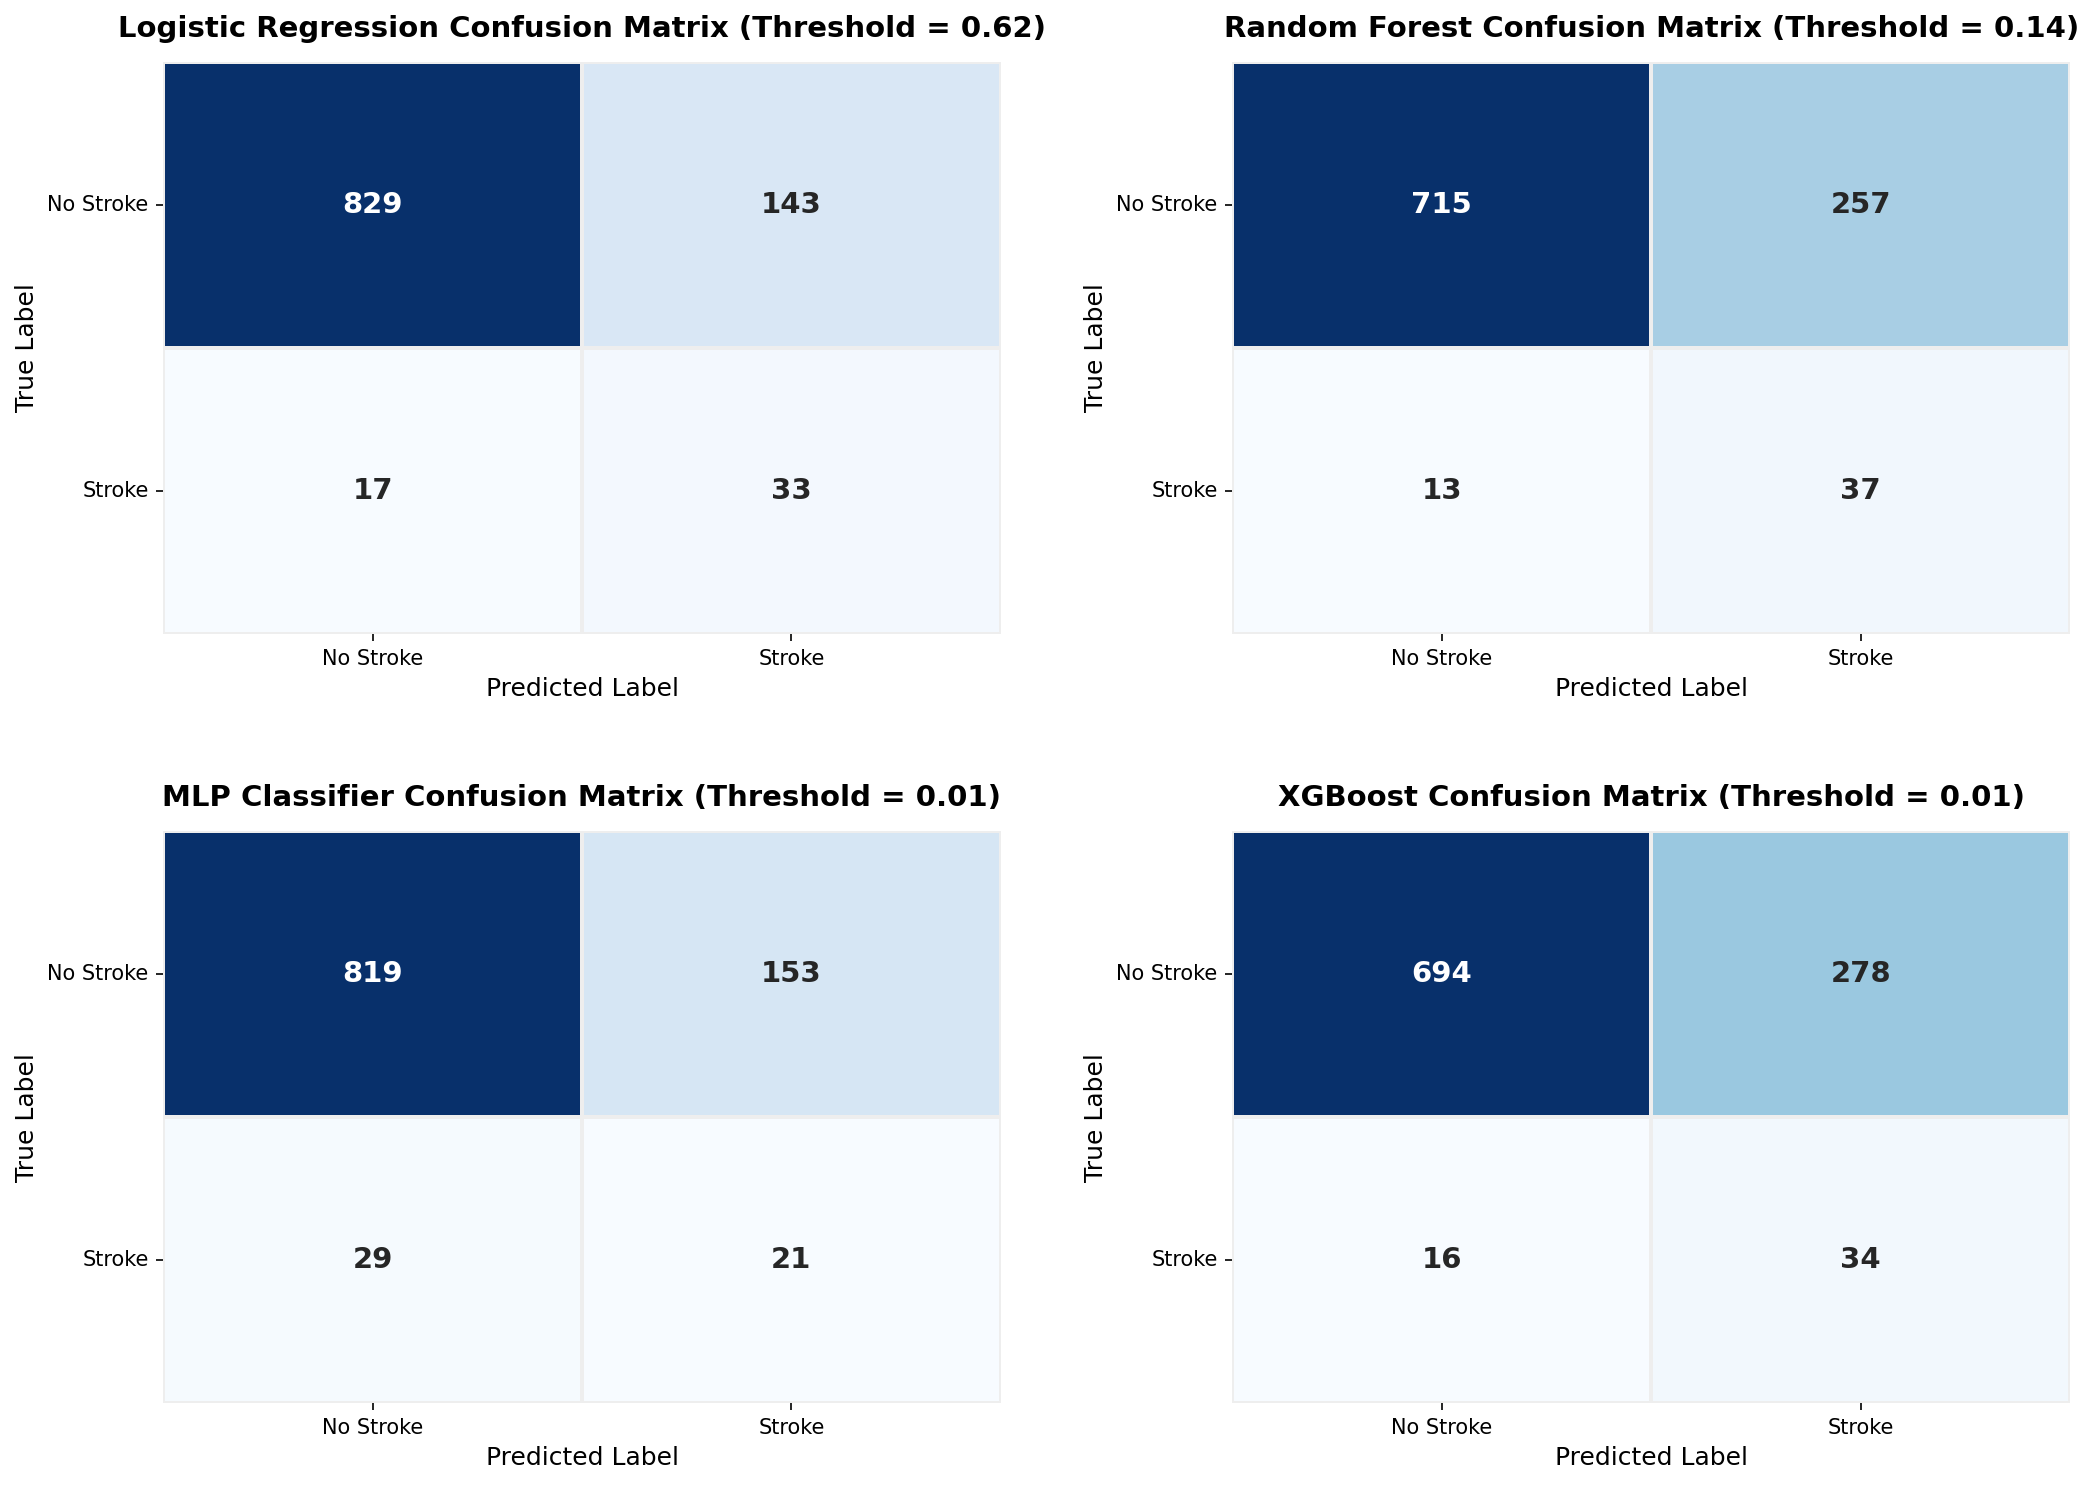

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import math
import numpy as np

num_models = len(models)
cols = 2
rows = math.ceil(num_models / cols)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(14, 5 * rows),
    dpi=150
)
axes = np.atleast_1d(axes).flatten()

for idx, (name, (model, _Xtr, _Xv, Xte, _ytr)) in enumerate(models.items()):
    threshold = 0.5
    if 'best_thresholds' in globals():
        matching_row = best_thresholds[best_thresholds["Model"] == name]
        if not matching_row.empty:
            threshold = matching_row["Threshold"].values[0]

    test_probs = model.predict_proba(Xte)[:, 1]
    test_preds = (test_probs >= threshold).astype(int)

    cm = confusion_matrix(y_test, test_preds)

    ax = axes[idx]
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax,
        linewidths=1,
        linecolor='#eee',
        annot_kws={'size': 14, 'weight': 'bold'}
    )

    ax.set_title(
        f'{name} Confusion Matrix (Threshold = {threshold:.2f})',
        fontsize=14,
        fontweight='bold',
        pad=12
    )
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xticklabels(['No Stroke', 'Stroke'], fontsize=10)
    ax.set_yticklabels(['No Stroke', 'Stroke'], fontsize=10, rotation=0)

for idx in range(num_models, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout(h_pad=4, w_pad=4)
plt.show()

##Summary, Limitations & Future Work

**What the numbers above say.** ... logistic regression is consistently the strongest single ranker on ROC AUC ... MLP the weakest ... AUC-weighted ensemble is chosen over any single learner because it lets the strongest model dominate the vote while absorbing a little signal from the tree-based models, and its threshold is tuned for F2 — appropriate since missing a stroke case is far more costly than a false alarm.

**Why precision stays low.** [explains the recall/precision trade-off given ~1-in-20 base rate]

**Limitations.** [SMOTE not adding real clinical info; weak raw correlations driving heavy feature engineering; imputation/capping not strictly train-only; missing clinical variables]

**Where this could go next.** [cost-sensitive learning, probability calibration, nested cross-validation, CatBoost comparison]